**======================================================================================================**
<p align="center"><b>PRE PROCESAMIENTO PROYECTO ANÁLISIS DE DATOS</b></p>

**======================================================================================================**
**Integrantes:***   
*   Vismark Abner Choque Cachi
*   Elizabeth Cusi Ancasi
  
**Materia: Analisis de Datos**  
**Docente: M.Sc. Madelina Loza Soliz**  
**Sigla: DAT-263**
**======================================================================================================**

# **DESCRIPCION DEL DATASET**

| **Columna** | **Descripción** |
|--------------|-----------------|
| **Carrera** | Indica la carrera universitaria o programa académico al que pertenece el estudiante. |
| **Gestión** | Año académico en el que se registró la nota del estudiante. |
| **Periodo** | Semestre o ciclo correspondiente dentro de la gestión académica. |
| **C.I.** | Número de cédula de identidad del estudiante, utilizado como identificador único. |
| **Sigla** | Código abreviado o identificador de la asignatura. |
| **Materia** | Nombre completo de la asignatura cursada por el estudiante. |
| **Nota** | Calificación final obtenida en la materia, expresada en una escala de 0 a 100. |


# **IMPORTACION DEL DATASET**
el dataset utilizado es **notas made** y se procedio a cambiar el nombre y no tener problemas al importar

In [23]:
import pandas as pd

# Cargar ambas hojas
hoja1 = pd.read_excel('data/originales/notas.xlsx', sheet_name=0)
hoja2 = pd.read_excel('data/originales/notas.xlsx', sheet_name=1)

print("Columnas hoja 1:", hoja1.columns.tolist())
print("Columnas hoja 2:", hoja2.columns.tolist())

# Encontrar columnas comunes
columnas_comunes = list(set(hoja1.columns) & set(hoja2.columns))
print("Columnas comunes:", columnas_comunes)

# Seleccionar solo las columnas comunes de ambas hojas
hoja1_comun = hoja1[columnas_comunes]
hoja2_comun = hoja2[columnas_comunes]

# Combinar
notas = pd.concat([hoja1_comun, hoja2_comun], ignore_index=True)
print(f"\nDatos combinados - Dimensiones: {notas.shape}")

Columnas hoja 1: ['Carrera', 'Gestión', 'Periodo', 'C.I.', 'Sigla', 'Materia', 'Nota']
Columnas hoja 2: ['Carrera', 'Gestión', 'Periodo', 'C.I.', 'Ap. Paterno', 'Ap. Materno', 'Nombres', 'Sigla', 'Materia', 'Nota', 'Nota Ponderada']
Columnas comunes: ['Sigla', 'Materia', 'Periodo', 'C.I.', 'Carrera', 'Gestión', 'Nota']

Datos combinados - Dimensiones: (21084, 7)


In [24]:
notas.head(10)

,Sigla,Materia,Periodo,C.I.,Carrera,Gestión,Nota
0,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,9205199,Biologia,2009,67
1,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,9205199,Biologia,2009,10
2,MAT-99,INTRODUCCIÓN A LA MATEMATICA,SEGUNDO,9205199,Biologia,2009,16
3,QMC-99,INTRODUCCIÓN A LA QUIMICA,SEGUNDO,9205199,Biologia,2009,35
4,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,8324224,Biologia,2009,51
5,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,8324224,Biologia,2009,51
6,MAT-99,INTRODUCCIÓN A LA MATEMATICA,SEGUNDO,8324224,Biologia,2009,51
7,QMC-99,INTRODUCCIÓN A LA QUIMICA,SEGUNDO,8324224,Biologia,2009,59
8,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,5623343,Biologia,2009,21
9,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,5623343,Biologia,2009,5


# **INFORMACION GENERAL DEL DATASET**

El dataset contiene un total de **21,084 registros** y **7 columnas**.  
A continuación se detalla la estructura del DataFrame:

In [25]:
notas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21084 entries, 0 to 21083
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Sigla    21084 non-null  object
 1   Materia  21084 non-null  object
 2   Periodo  21084 non-null  object
 3   C.I.     21084 non-null  object
 4   Carrera  21084 non-null  object
 5   Gestión  21084 non-null  int64 
 6   Nota     21084 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 1.1+ MB


# **RESUMEN DEL DATASET**

In [26]:
resumen = notas.describe(include='all')
# Transpuesta
resumen_T = resumen.T
resumen_T['Tipo_dato'] = resumen.dtypes
resumen_T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,Tipo_dato
Sigla,21084,11,MAT-99,5130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Materia,21084,11,INTRODUCCIÓN A LA MATEMATICA,5130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Periodo,21084,5,SEGUNDO,10209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
C.I.,21084.0,4360.0,10945732.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,float64
Carrera,21084,7,Informática,8445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Gestión,21084.0,NaN,NaN,NaN,2017.248577,3.645201,2009.0,2015.0,2019.0,2020.0,2021.0,float64
Nota,21084.0,NaN,NaN,NaN,33.82361,28.139549,0.0,4.0,32.0,57.0,214.0,float64


# **1) TRATAMIENTO DE DATOS FALTANTES**

En esta sección se identificarán los **valores faltantes** del dataset y se aplicarán las **estrategias necesarias para su manejo**, asegurando que los datos estén listos para el análisis.


In [27]:
#GENERACION DE UNA TABLA DE RESUMEN DE DATOS FALTANTES
datos_faltantes = pd.DataFrame(columns = ['COLUMNA','NAN','VACIOS','TOTAL_FALTANTES'],dtype = str)
for ids,colum in enumerate(notas.columns):
  cant_nan = notas[colum].isna().sum()
  if(notas[colum].dtype=='object'):
    cant_vacios = (notas[colum].astype(str).str.strip() == '').sum()
  else:
    cant_vacios = 0
  datos_faltantes.loc[ids,'COLUMNA'] = colum
  datos_faltantes.loc[ids,'NAN'] = cant_nan
  datos_faltantes.loc[ids,'VACIOS'] = cant_vacios
  datos_faltantes.loc[ids,'TOTAL_FALTANTES'] = cant_nan+cant_vacios


datos_faltantes



,COLUMNA,NAN,VACIOS,TOTAL_FALTANTES
0,Sigla,0,0,0
1,Materia,0,0,0
2,Periodo,0,0,0
3,C.I.,0,0,0
4,Carrera,0,0,0
5,Gestión,0,0,0
6,Nota,0,0,0


como se observan valores faltantes se procede con el **TRATAMIENTO DE OUTLIERS**

# **2) TRATAMIENTO DE OUTLIERS**


Se realizó un análisis gráfico de las variables numéricas del dataset `notas`, específicamente **Gestión** y **Nota**, utilizando histogramas y boxplots para explorar la distribución, valores atípicos y resumen estadístico.


Variables numéricas a graficar:
1: Gestión
2: Nota

1: Gestión
  Valores faltantes: 0
  Min: 2009, Max: 2021, Media: 2017.25, Mediana: 2019.0
  Q1: 2015.0, Q3: 2020.0, IQR: 5.0
  Outliers: 0



2: Nota
  Valores faltantes: 0
  Min: 0, Max: 214, Media: 33.82, Mediana: 32.0
  Q1: 4.0, Q3: 57.0, IQR: 53.0
  Outliers: 1


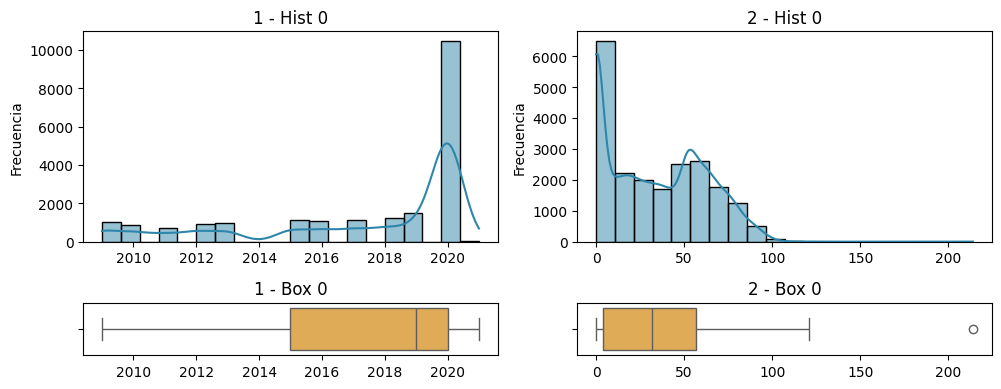

In [28]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables numéricas
num_cols = [c for c in notas.columns if notas[c].dtype in ['int64','float64']]

# Imprimir mini-report con números
print("Variables numéricas a graficar:")
for i, col in enumerate(num_cols, start=1):
    print(f"{i}: {col}")

def plot_num_with_box(data, cols):
    n = len(cols)
    cols_per_row = 4
    n_rows = math.ceil(n / cols_per_row)

    fig, axes = plt.subplots(2 * n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows),
                             gridspec_kw={'height_ratios': [4, 1] * n_rows})

    if n_rows == 1:
        axes = np.array(axes)
    if axes.ndim == 1:
        axes = axes.reshape(2*n_rows, cols_per_row)

    for idx, col in enumerate(cols):
        row_idx = (idx // cols_per_row) * 2
        col_idx = idx % cols_per_row
        graf_num = idx + 1

        col_data = data[col].dropna()
        n_missing = data[col].isna().sum()

        # Estadísticas
        q1 = col_data.quantile(0.25)
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        min_val = col_data.min()
        max_val = col_data.max()
        median = col_data.median()
        mean = col_data.mean()
        # Outliers
        outliers = col_data[(col_data < q1 - 1.5*iqr) | (col_data > q3 + 1.5*iqr)]
        n_outliers = len(outliers)

        # Print resumen
        print(f"\n{graf_num}: {col}")
        print(f"  Valores faltantes: {n_missing}")
        print(f"  Min: {min_val}, Max: {max_val}, Media: {mean:.2f}, Mediana: {median}")
        print(f"  Q1: {q1}, Q3: {q3}, IQR: {iqr}")
        print(f"  Outliers: {n_outliers}")

        # Títulos con número y cantidad de faltantes
        title_hist = f'{graf_num} - Hist {n_missing}'
        title_box = f'{graf_num} - Box {n_missing}'

        # Histograma
        sns.histplot(data=data, x=col, ax=axes[row_idx, col_idx], bins=20, kde=True, color='#2E86AB')
        axes[row_idx, col_idx].set_title(title_hist)
        axes[row_idx, col_idx].set_xlabel("")
        axes[row_idx, col_idx].set_ylabel("Frecuencia")

        # Boxplot
        if col_data.nunique() >= 2:
            color = '#F08080' if n_missing > 0 else '#F5B041'
            sns.boxplot(data=data, x=col, ax=axes[row_idx+1, col_idx], color=color)
        else:
            axes[row_idx+1, col_idx].text(0.5, 0.5, 'No hay datos suficientes', ha='center', va='center')
        axes[row_idx+1, col_idx].set_title(title_box)
        axes[row_idx+1, col_idx].set_xlabel("")
        axes[row_idx+1, col_idx].set_ylabel("")

    # Ocultar ejes vacíos
    for j in range(n, n_rows*cols_per_row):
        for i in [0,1]:
            axes[(j//cols_per_row)*2 + i, j%cols_per_row].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_num_with_box(notas, num_cols)


**Variables numéricas**
- **Gestión**: Representa el año académico de cada registro.
  - Valores entre 2009 y 2021.
  - Media: 2014.58, Mediana: 2015.
  - Rango intercuartílico (IQR): 6.
  - No se detectaron valores faltantes ni outliers.

- **Nota**: Calificación obtenida por los estudiantes.
  - Valores entre 0 y 214, con media de 32.24 y mediana 28.
  - Rango intercuartílico (IQR): 47.
  - Se detectó 1 valor atípico (mayor a 100), indicando un posible error en los datos.


**Grafico para la identificacion de los valores atipicos**

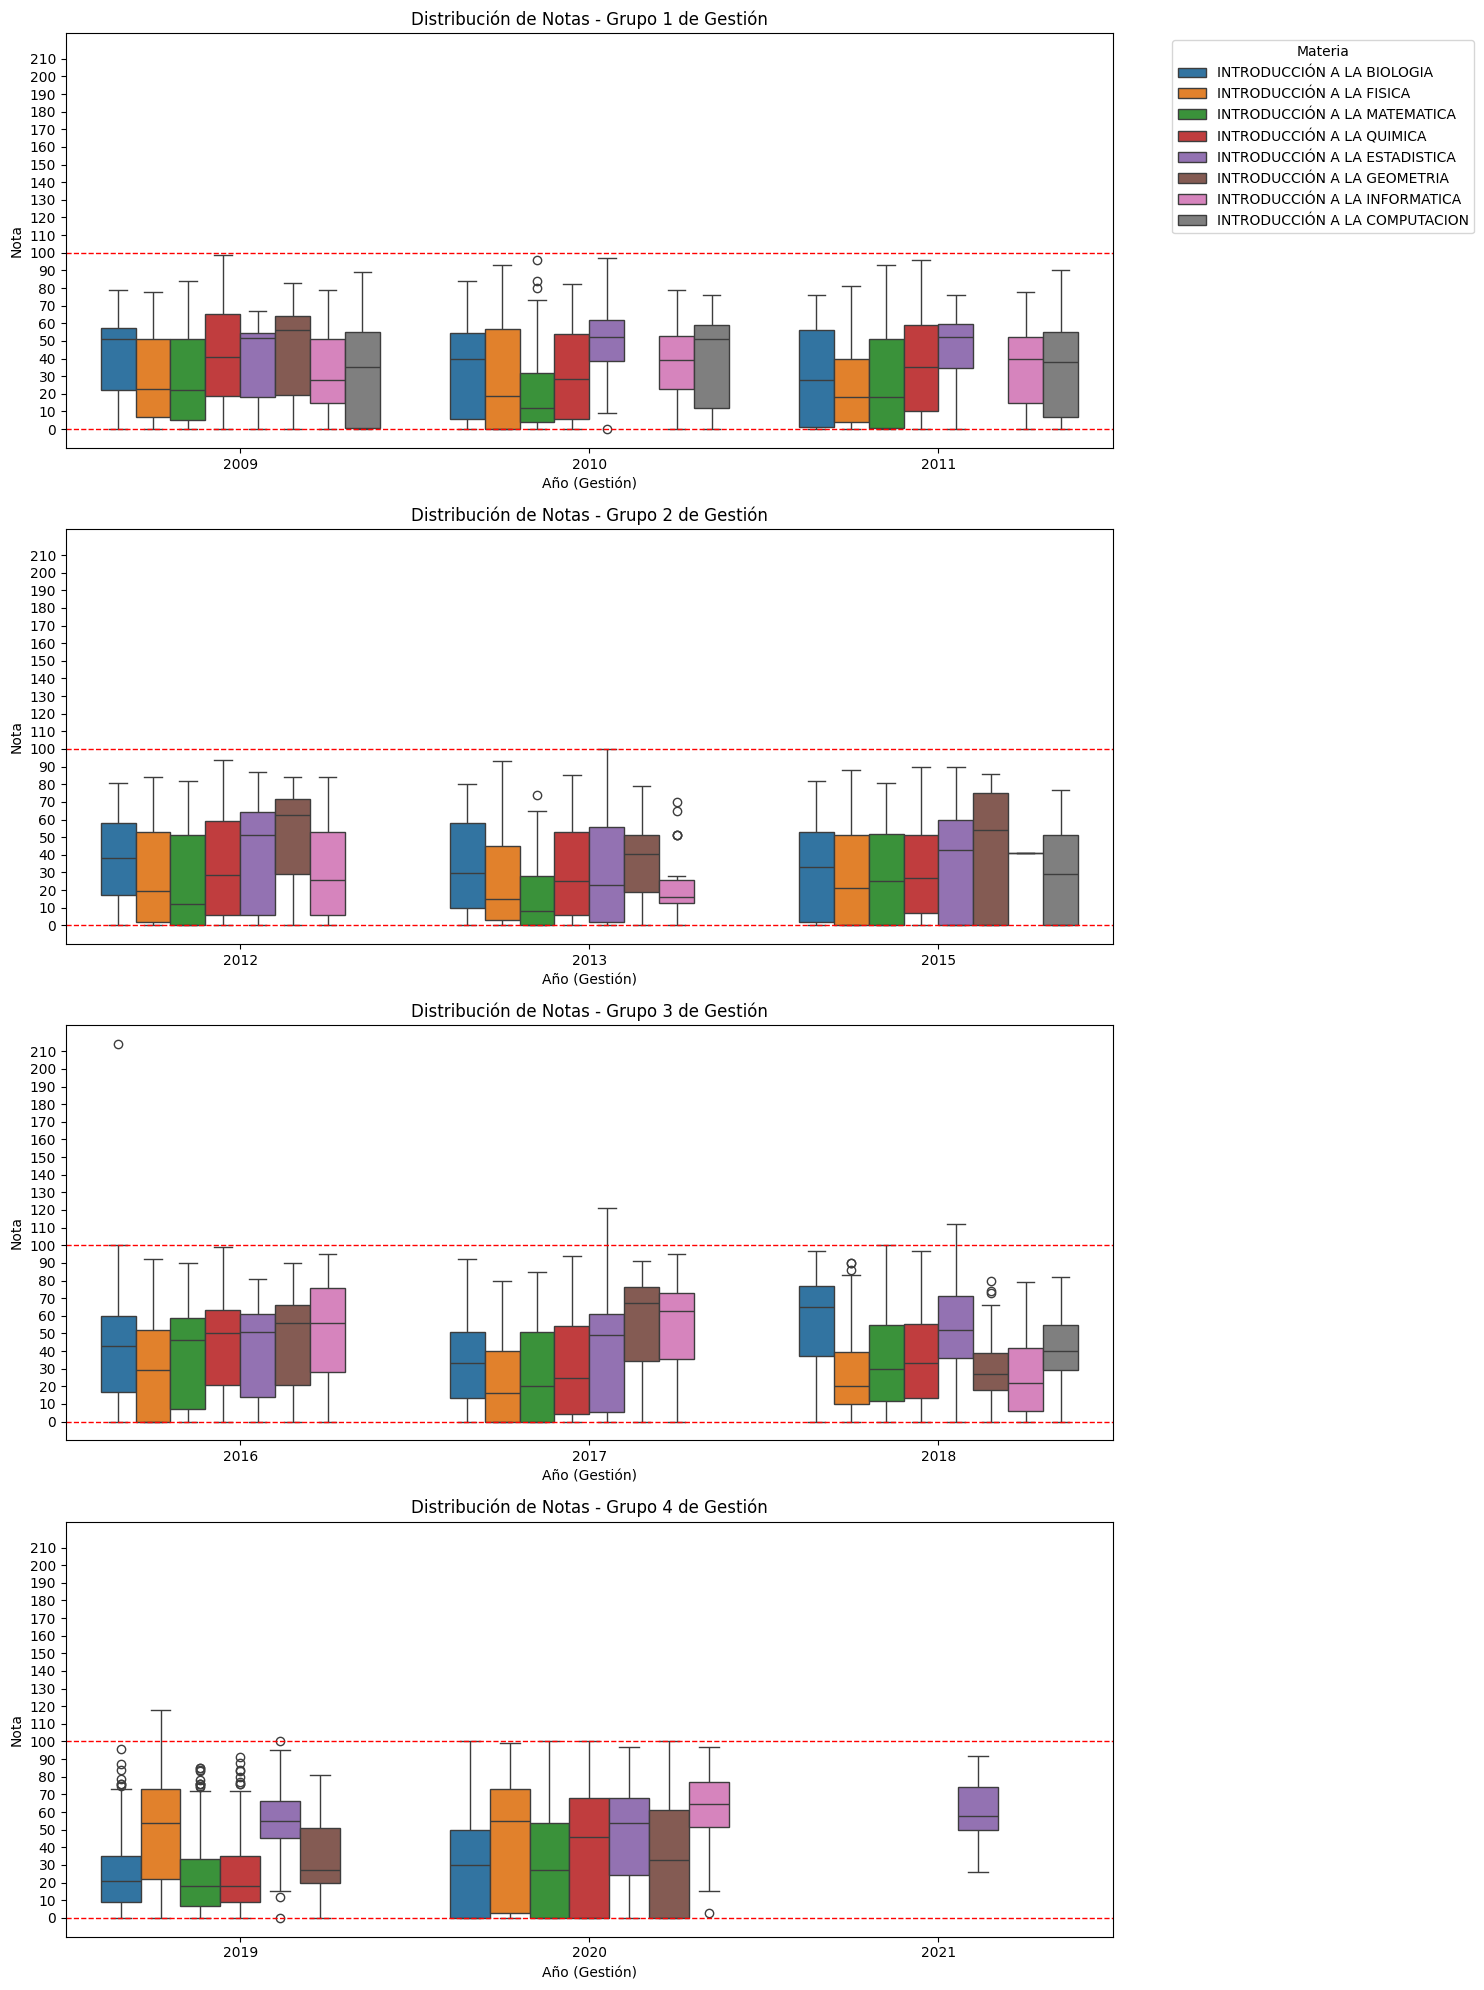

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Obtener los años únicos y ordenarlos
años = sorted(notas['Gestión'].unique())
n = len(años)
cuarto = n // 4

# Dividir los años en 4 grupos
grupos_años = [
    años[:cuarto],
    años[cuarto:2*cuarto],
    años[2*cuarto:3*cuarto],
    años[3*cuarto:]
]

# Crear subplots 4x1
fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharey=True)

# Definir ticks más detallados para el eje y
min_nota = notas['Nota'].min()
max_nota = notas['Nota'].max()
yticks = np.arange(min_nota, max_nota + 1, 10)  # ajustar según necesites

for i, grupo in enumerate(grupos_años):
    ax = axes[i]
    sns.boxplot(
        x='Gestión', y='Nota', hue='Materia',
        data=notas[notas['Gestión'].isin(grupo)],
        ax=ax
    )
    ax.set_title(f'Distribución de Notas - Grupo {i+1} de Gestión')
    ax.set_xlabel('Año (Gestión)')
    ax.set_ylabel('Nota')
    ax.set_yticks(yticks)  # aplicar los ticks detallados

    # Agregar línea segmentada horizontal en 100 y 0
    ax.axhline(100, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)

    if i != 0:  
        ax.get_legend().remove()

axes[0].legend(title='Materia', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


Como se puede observar aunque utilicemos el IQR para la detección de valores atípicos, este no es del todo correcto por que tambien debemos tomar en cuenta el valor maximo y minimo del dataset es decir las notas no pueden ser superior a 100 e inferiores a 0 por lo cual pasamos a identificar estos datos y tratarlos 

In [30]:
# Filtrar notas fuera del rango 0-100
notas_fuera_rango = notas[(notas['Nota'] > 100) | (notas['Nota'] < 0)]

# Mostrar como DataFrame
if not notas_fuera_rango.empty:
    print("Datos de personas con notas fuera del rango 0-100:")
    display(notas_fuera_rango) 
else:
    print("No hay notas fuera del rango 0-100.")

print("La cantidad de datos fuera de los rangos permitidos son:", len(notas_fuera_rango))


Datos de personas con notas fuera del rango 0-100:


,Sigla,Materia,Periodo,C.I.,Carrera,Gestión,Nota
3876,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,13847410,Biologia,2019,112
3896,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,9208205,Biologia,2019,101
3936,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,8428623,Biologia,2019,103
4020,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,6865282,Biologia,2019,104
4545,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,PRIMERO,5995211,Ciencias Químicas,2016,214
6966,COM-99,INTRODUCCIÓN A LA COMPUTACION,SEGUNDO,9872948,Estadística,2017,121
7190,COM-99,INTRODUCCIÓN A LA COMPUTACION,SEGUNDO,8440561,Estadística,2018,104
7212,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,10954108,Estadística,2019,101
7224,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,12863122,Estadística,2019,107
7232,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,9175283,Estadística,2019,112


La cantidad de datos fuera de los rangos permitidos son: 23


In [31]:
# Obtener todos los C.I. de estudiantes con notas fuera del rango
ci_fuera_rango = notas_fuera_rango['C.I.'].unique()

# Filtrar todas las filas de esos estudiantes
notas_estudiantes_fuera_rango = notas[notas['C.I.'].isin(ci_fuera_rango)]

# Mostrar resultados como DataFrame
notas_estudiantes_fuera_rango



,Sigla,Materia,Periodo,C.I.,Carrera,Gestión,Nota
3875,FIS-99,INTRODUCCIÓN A LA FISICA,PRIMERO,13847410,Biologia,2019,29
3876,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,13847410,Biologia,2019,112
3877,MAT-99,INTRODUCCIÓN A LA MATEMATICA,PRIMERO,13847410,Biologia,2019,18
3878,QMC-99,INTRODUCCIÓN A LA QUIMICA,PRIMERO,13847410,Biologia,2019,26
3895,FIS-99,INTRODUCCIÓN A LA FISICA,PRIMERO,9208205,Biologia,2019,29
...,...,...,...,...,...,...,...
9773,QMC-99,INTRODUCCIÓN A LA QUIMICA,PRIMERO,9083778,Física,2019,15
9808,PSA,PRUEBA DE SUFICIENCIA ACADEMICA,PRIMERO (PSA),8303575,Física,2019,42
9814,PSA,PRUEBA DE SUFICIENCIA ACADEMICA,PRIMERO (PSA),9211370,Física,2019,27
10033,PSA,PRUEBA DE SUFICIENCIA ACADEMICA,SEGUNDO (PSA),9211370,Física,2019,77


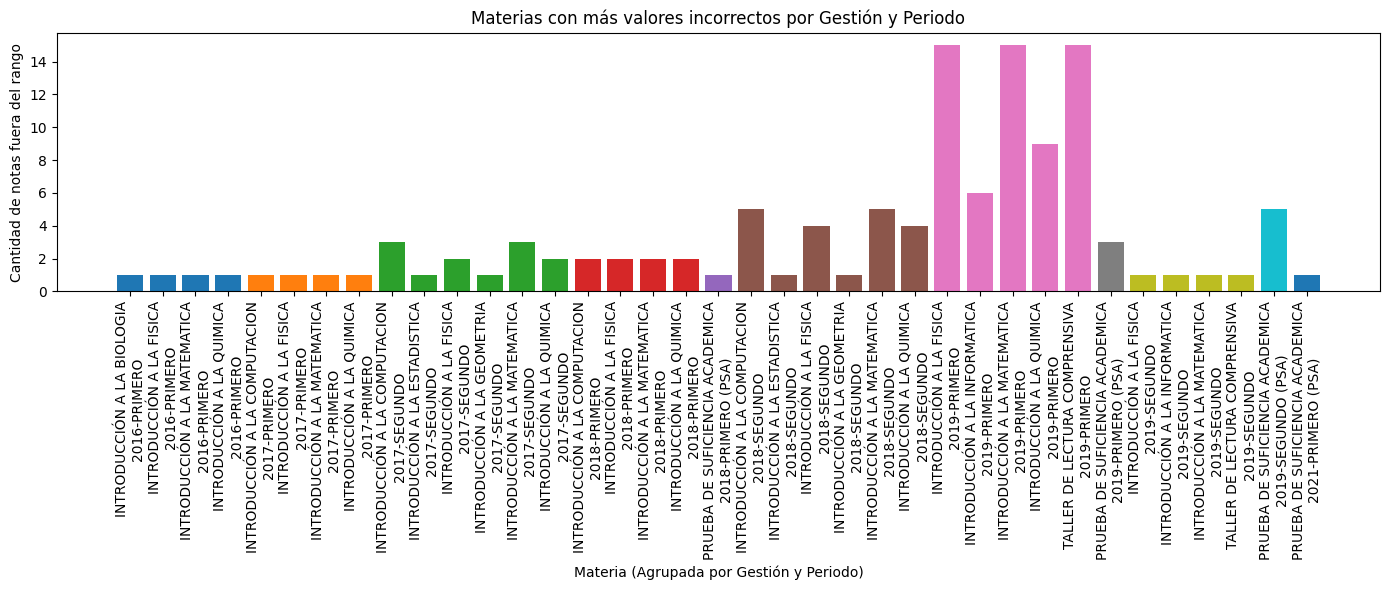

In [32]:
conteo_outliers = (
    notas_estudiantes_fuera_rango
    .groupby(['Gestión', 'Periodo', 'Materia'])
    .size()
    .reset_index(name='Cantidad_outliers')
)


# Gráfico

plt.figure(figsize=(14, 6))

# Hacemos un gráfico de barras
for (gestion, periodo), subdf in conteo_outliers.groupby(["Gestión", "Periodo"]):
    plt.bar(
        subdf["Materia"] + f"\n{gestion}-{periodo}",
        subdf["Cantidad_outliers"]
    )

plt.xticks(rotation=90)
plt.xlabel("Materia (Agrupada por Gestión y Periodo)")
plt.ylabel("Cantidad de notas fuera del rango")
plt.title("Materias con más valores incorrectos por Gestión y Periodo")
plt.tight_layout()
plt.show()

Primeras filas de las notas válidas:


,Sigla,Materia,Periodo,C.I.,Carrera,Gestión,Nota
0,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,9205199,Biologia,2009,67
1,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,9205199,Biologia,2009,10
2,MAT-99,INTRODUCCIÓN A LA MATEMATICA,SEGUNDO,9205199,Biologia,2009,16
3,QMC-99,INTRODUCCIÓN A LA QUIMICA,SEGUNDO,9205199,Biologia,2009,35
4,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,8324224,Biologia,2009,51
5,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,8324224,Biologia,2009,51
6,MAT-99,INTRODUCCIÓN A LA MATEMATICA,SEGUNDO,8324224,Biologia,2009,51
7,QMC-99,INTRODUCCIÓN A LA QUIMICA,SEGUNDO,8324224,Biologia,2009,59
8,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,5623343,Biologia,2009,21
9,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,5623343,Biologia,2009,5



Media: 33.74, Mediana: 32.00, Desviación estándar: 28.03
Porcentaje de datos dentro de ±1 desviación estándar: 53.63%
Cantidad de notas bajas (por debajo de media - 1σ): 5571
Cantidad de notas altas (por encima de media + 1σ): 4196


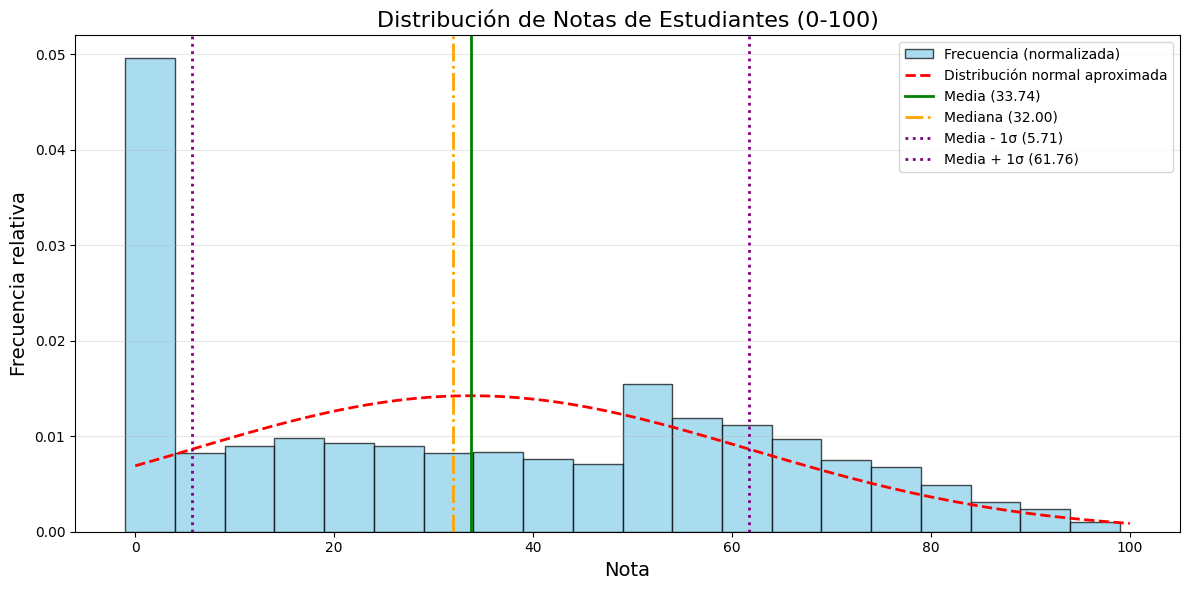

In [33]:
from scipy.stats import norm

# Filtrar datos válidos (0 <= nota <= 100)
notas_validas = notas[(notas['Nota'] >= 0) & (notas['Nota'] <= 100)].copy()

# Mostrar las primeras filas para ver los datos
print("Primeras filas de las notas válidas:")
display(notas_validas.head(10))  
# display completa el DataFrame, si es consola puedes usar print(notas_validas)

# Calcular estadísticos
media = notas_validas['Nota'].mean()
mediana = notas_validas['Nota'].median()
desviacion = notas_validas['Nota'].std()

print(f"\nMedia: {media:.2f}, Mediana: {mediana:.2f}, Desviación estándar: {desviacion:.2f}")

# Calcular porcentaje dentro de ±1 desviación estándar
dentro_1sigma = notas_validas[(notas_validas['Nota'] >= media - desviacion) & (notas_validas['Nota'] <= media + desviacion)]
porcentaje_1sigma = len(dentro_1sigma) / len(notas_validas) * 100
print(f"Porcentaje de datos dentro de ±1 desviación estándar: {porcentaje_1sigma:.2f}%")

# Identificar valores extremos
valores_bajos = notas_validas[notas_validas['Nota'] < media - desviacion]
valores_altos = notas_validas[notas_validas['Nota'] > media + desviacion]
print(f"Cantidad de notas bajas (por debajo de media - 1σ): {len(valores_bajos)}")
print(f"Cantidad de notas altas (por encima de media + 1σ): {len(valores_altos)}")

# Graficar
bins = np.arange(int(notas_validas['Nota'].min())-1, int(notas_validas['Nota'].max())+2, 5)

plt.figure(figsize=(12,6))
plt.hist(notas_validas['Nota'], bins=bins, color='skyblue', edgecolor='black', alpha=0.7, density=True, label='Frecuencia (normalizada)')
x = np.linspace(notas_validas['Nota'].min(), notas_validas['Nota'].max(), 100)
plt.plot(x, norm.pdf(x, media, desviacion), color='red', linestyle='--', linewidth=2, label='Distribución normal aproximada')

# Líneas estadísticas
plt.axvline(media, color='green', linestyle='-', linewidth=2, label=f'Media ({media:.2f})')
plt.axvline(mediana, color='orange', linestyle='-.', linewidth=2, label=f'Mediana ({mediana:.2f})')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=2, label=f'Media - 1σ ({media - desviacion:.2f})')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=2, label=f'Media + 1σ ({media + desviacion:.2f})')

plt.title('Distribución de Notas de Estudiantes (0-100)', fontsize=16)
plt.xlabel('Nota', fontsize=14)
plt.ylabel('Frecuencia relativa', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Observación
- El estudiante tiene **una nota extremadamente alta** en Biología comparada con las demás materias.  
- Dado que es un **outlier evidente**, este fue un error lo que procedera hacer es reemplazar este valor en base a la mediana de la nota obtenida en esa materia y esa gestion.


In [34]:
notas_corregidas = notas.copy()

for idx, fila in notas_fuera_rango.iterrows():
    ci = fila['C.I.']
    materia = fila['Materia']
    gestion = fila['Gestión']
    nota_original = fila['Nota']

    # Calcular la mediana real (solo valores válidos)
    mediana = notas_corregidas[
        (notas_corregidas['Materia'] == materia) &
        (notas_corregidas['Gestión'] == gestion) &
        (notas_corregidas['Nota'] >= 0) &
        (notas_corregidas['Nota'] <= 100)
    ]['Nota'].median()

    # Si no hay suficientes datos para calcular
    if pd.isna(mediana):
        print(f"No se pudo calcular la mediana para {materia} ({gestion}). Saltado.")
        continue

    # Reemplazar el valor atípico
    notas_corregidas.loc[idx, 'Nota'] = mediana
    print(f"Corregido C.I. {ci} | {materia} ({gestion}) : {nota_original} → {mediana}")

# Mostrar tabla final corregida de esos estudiantes
print("\n=== Notas corregidas de estudiantes con valores fuera del rango ===")
display(notas_corregidas[notas_corregidas['C.I.'].isin(ci_fuera_rango)])

Corregido C.I. 13847410 | TALLER DE LECTURA COMPRENSIVA (2019) : 112 → 52.0
Corregido C.I. 9208205 | TALLER DE LECTURA COMPRENSIVA (2019) : 101 → 52.0
Corregido C.I. 8428623 | TALLER DE LECTURA COMPRENSIVA (2019) : 103 → 52.0
Corregido C.I. 6865282 | TALLER DE LECTURA COMPRENSIVA (2019) : 104 → 52.0
Corregido C.I. 5995211 | INTRODUCCIÓN A LA BIOLOGIA (2016) : 214 → 43.0
Corregido C.I. 9872948 | INTRODUCCIÓN A LA COMPUTACION (2017) : 121 → 44.0
Corregido C.I. 8440561 | INTRODUCCIÓN A LA COMPUTACION (2018) : 104 → 52.0
Corregido C.I. 10954108 | TALLER DE LECTURA COMPRENSIVA (2019) : 101 → 52.0
Corregido C.I. 12863122 | TALLER DE LECTURA COMPRENSIVA (2019) : 107 → 52.0
Corregido C.I. 9175283 | TALLER DE LECTURA COMPRENSIVA (2019) : 112 → 52.0
Corregido C.I. 13500385 | TALLER DE LECTURA COMPRENSIVA (2019) : 118 → 52.0
Corregido C.I. 13764109 | TALLER DE LECTURA COMPRENSIVA (2019) : 102 → 52.0
Corregido C.I. 8360254 | TALLER DE LECTURA COMPRENSIVA (2019) : 106 → 52.0
Corregido C.I. 11110971

,Sigla,Materia,Periodo,C.I.,Carrera,Gestión,Nota
3875,FIS-99,INTRODUCCIÓN A LA FISICA,PRIMERO,13847410,Biologia,2019,29
3876,LIN-99,TALLER DE LECTURA COMPRENSIVA,PRIMERO,13847410,Biologia,2019,52
3877,MAT-99,INTRODUCCIÓN A LA MATEMATICA,PRIMERO,13847410,Biologia,2019,18
3878,QMC-99,INTRODUCCIÓN A LA QUIMICA,PRIMERO,13847410,Biologia,2019,26
3895,FIS-99,INTRODUCCIÓN A LA FISICA,PRIMERO,9208205,Biologia,2019,29
...,...,...,...,...,...,...,...
9773,QMC-99,INTRODUCCIÓN A LA QUIMICA,PRIMERO,9083778,Física,2019,15
9808,PSA,PRUEBA DE SUFICIENCIA ACADEMICA,PRIMERO (PSA),8303575,Física,2019,42
9814,PSA,PRUEBA DE SUFICIENCIA ACADEMICA,PRIMERO (PSA),9211370,Física,2019,27
10033,PSA,PRUEBA DE SUFICIENCIA ACADEMICA,SEGUNDO (PSA),9211370,Física,2019,77



Realizada la correcion procedemos a ver la nueva distribucion de los datos, y ya no presentamos valores atipicos extremos

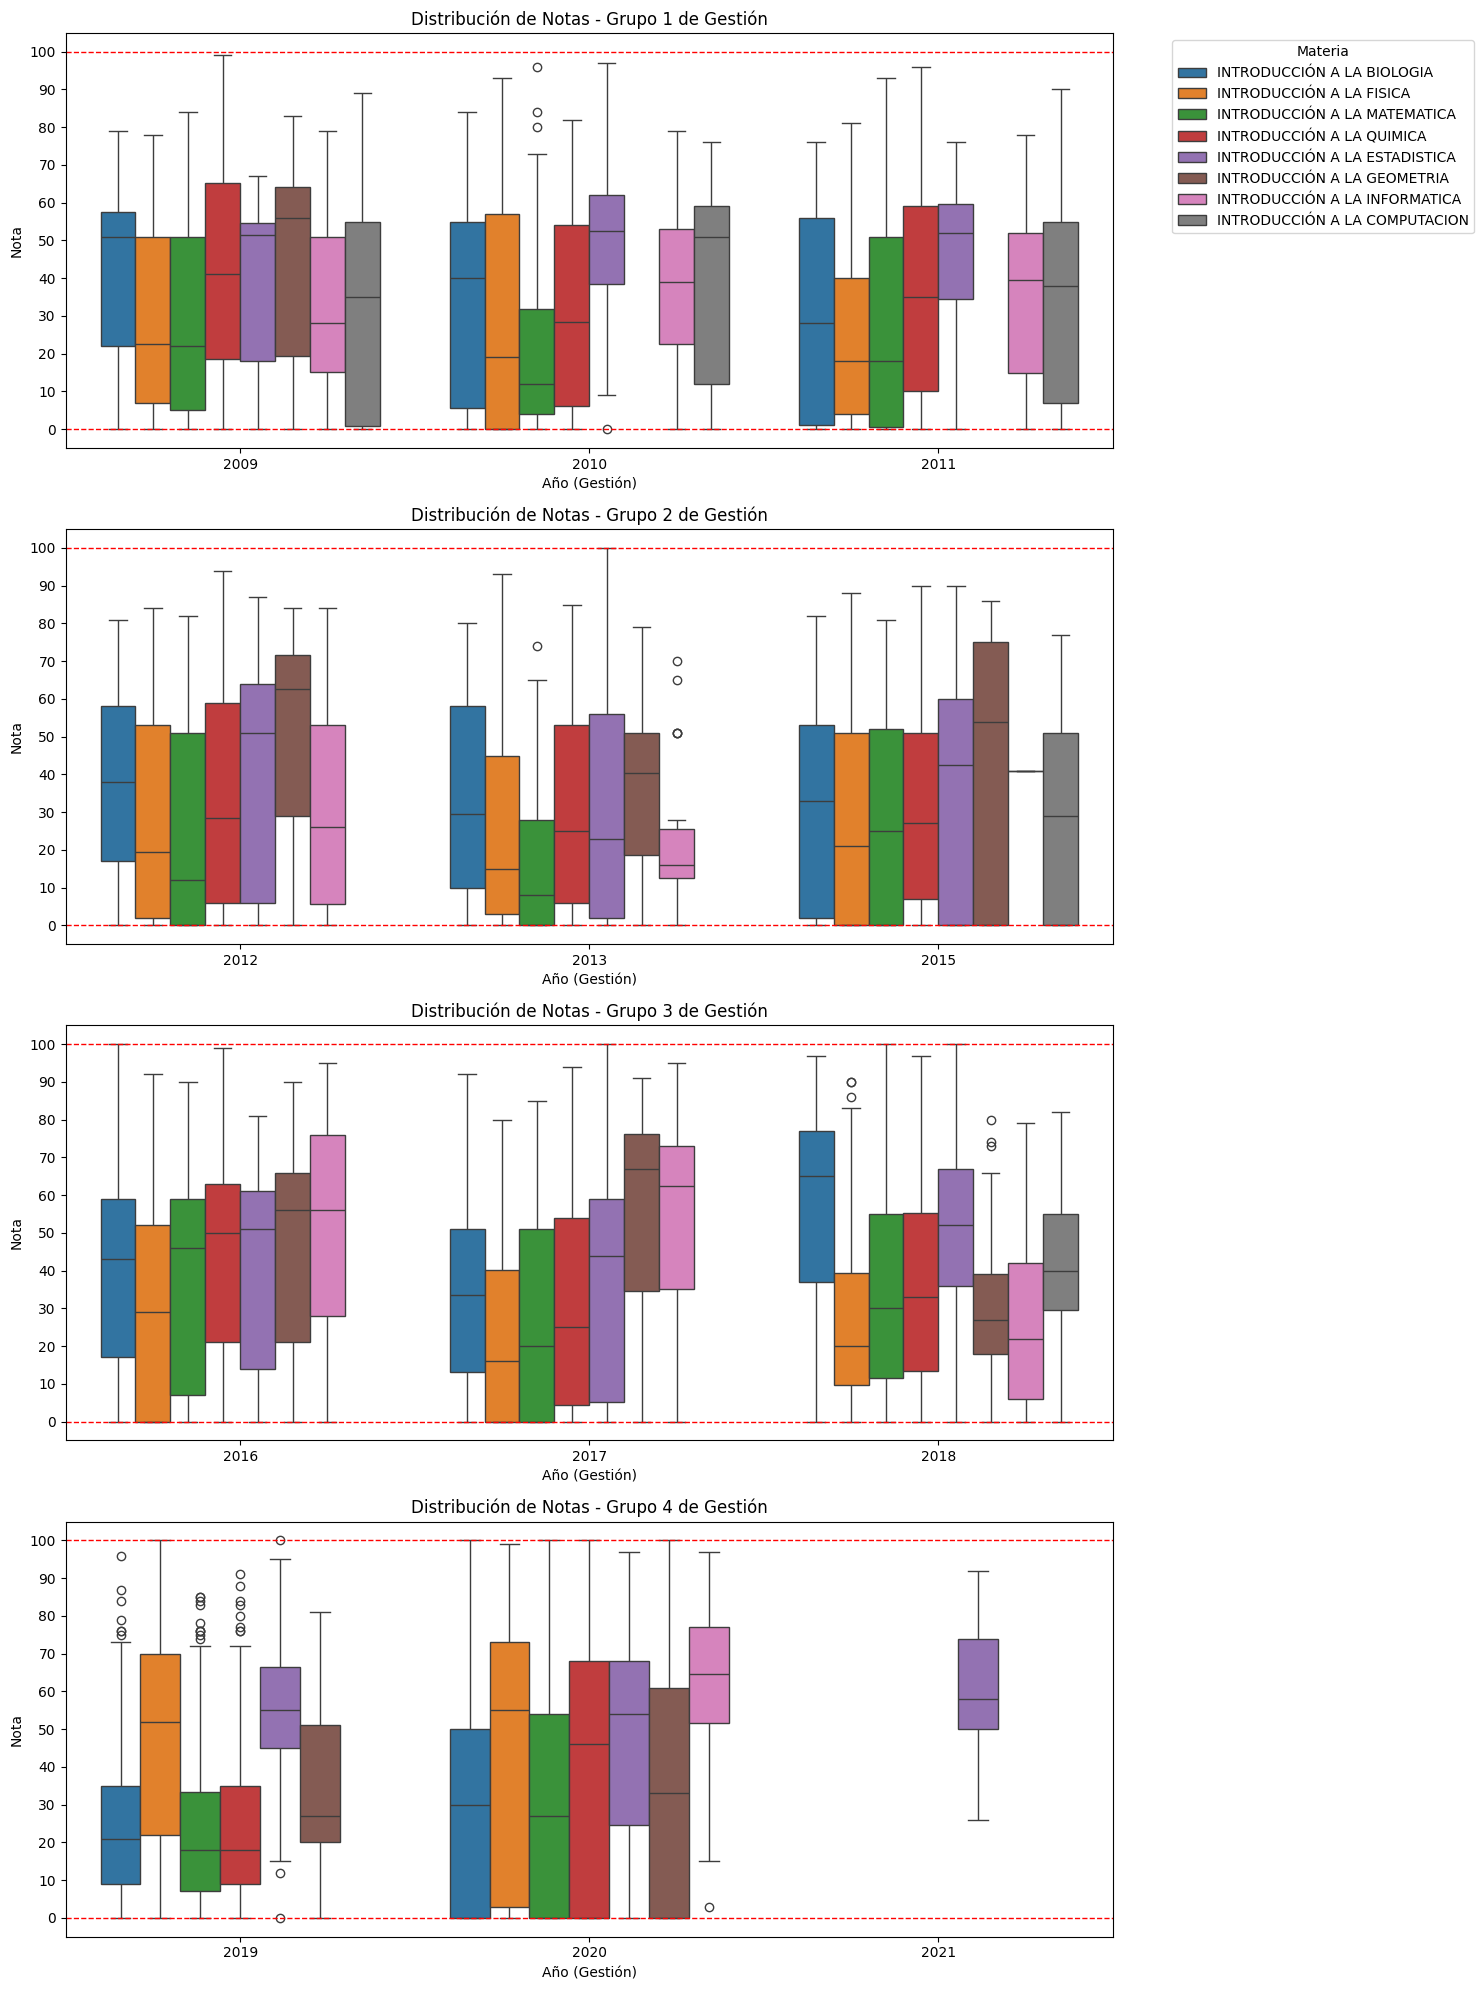

In [35]:

# Obtener los años únicos y ordenarlos
años = sorted(notas_corregidas['Gestión'].unique())
n = len(años)
cuarto = n // 4

# Dividir los años en 4 grupos
grupos_años = [
    años[:cuarto],
    años[cuarto:2*cuarto],
    años[2*cuarto:3*cuarto],
    años[3*cuarto:]
]

# Crear subplots 4x1
fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharey=True)

# Definir ticks más detallados para el eje y
min_nota = notas_corregidas['Nota'].min()
max_nota = notas_corregidas['Nota'].max()
yticks = np.arange(min_nota, max_nota + 1, 10)  # ajustar según necesites

for i, grupo in enumerate(grupos_años):
    ax = axes[i]
    sns.boxplot(
        x='Gestión', y='Nota', hue='Materia',
        data=notas_corregidas[notas_corregidas['Gestión'].isin(grupo)],
        ax=ax
    )
    ax.set_title(f'Distribución de Notas - Grupo {i+1} de Gestión')
    ax.set_xlabel('Año (Gestión)')
    ax.set_ylabel('Nota')
    ax.set_yticks(yticks)  # aplicar los ticks detallados

    # Agregar línea segmentada horizontal en 100 y 0
    ax.axhline(100, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)

    if i != 0:  
        ax.get_legend().remove()

axes[0].legend(title='Materia', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


# **3) CONVERSION DE TIPOS DE DATOS**
En esta seccion los datos ya se encuentran en el tipo de dato correcto por lo que procedera directamente al proximo paso

In [36]:
notas_corregidas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21084 entries, 0 to 21083
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Sigla    21084 non-null  object
 1   Materia  21084 non-null  object
 2   Periodo  21084 non-null  object
 3   C.I.     21084 non-null  object
 4   Carrera  21084 non-null  object
 5   Gestión  21084 non-null  int64 
 6   Nota     21084 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 1.1+ MB


In [37]:
notas_corregidas['C.I.'] = notas_corregidas['C.I.'].astype(str).str.strip()


Se hace una normalizacion de la columna carrera ya que esta tiene  'Cs. Químicas": "Ciencias Química' que significan lo mismo por que pasamos a utilizar solo uno de ellos

In [38]:
print(notas_corregidas["Carrera"].unique())
notas_corregidas["Carrera"] = notas_corregidas["Carrera"].replace({
    "Cs. Químicas": "Ciencias Químicas"
})

print(notas_corregidas["Carrera"].unique())

['Biologia' 'Ciencias Químicas' 'Cs. Químicas' 'Estadística' 'Física'
 'Informática' 'Matemática']
['Biologia' 'Ciencias Químicas' 'Estadística' 'Física' 'Informática'
 'Matemática']


# **4) TRATAMIENTO DE DATOS DUPLICADOS**

Busqueda de datos duplicados considerando todas las columnas

In [39]:
# Cantidad total de filas duplicadas (considerando todas las columnas)
duplicados_totales = notas_corregidas.duplicated().sum()
duplicados_totales


np.int64(0)

Busqueda de datos en base a columnas clave, principales

In [40]:
duplicados_claves = notas_corregidas.duplicated(subset=["C.I.", "Sigla", "Gestión", "Periodo","Carrera"]).sum()
duplicados_claves


np.int64(0)

# **5) CREACION DE NUEVAS VARIABLES**

In [41]:
notas_corregidas.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21084 entries, 0 to 21083
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Sigla    21084 non-null  object
 1   Materia  21084 non-null  object
 2   Periodo  21084 non-null  object
 3   C.I.     21084 non-null  object
 4   Carrera  21084 non-null  object
 5   Gestión  21084 non-null  int64 
 6   Nota     21084 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 1.1+ MB


In [42]:
materias_por_carrera = (
    notas[notas["Nota"] != -1]                 
    .groupby("Carrera")["Sigla"]
    .unique()
)

materias_por_carrera

conteo_materias = (
    notas[notas["Nota"] != -1]
    .groupby("Carrera")["Sigla"]
    .nunique()
    .reset_index(name="Cantidad_materias_unicas")
)

conteo_materias


,Carrera,Cantidad_materias_unicas
0,Biologia,9
1,Ciencias Químicas,7
2,Cs. Químicas,6
3,Estadística,10
4,Física,9
5,Informática,7
6,Matemática,5


In [43]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# ================================================
# 1) Función de análisis por carrera y gestión
# ================================================
def analizar_dificultad_por_carrera(df, carrera, gestion):
    # Filtrar por carrera y gestión
    df_car = df[(df["Carrera"] == carrera) & (df["Gestión"] == gestion)].copy()
    
    resultados = []
    
    for materia, grupo in df_car.groupby("Sigla"):
        # Filtrar solo notas válidas
        notas_validas = grupo[grupo["Nota"] != -1]["Nota"]
        if notas_validas.empty:
            continue

        total = len(notas_validas)
        aprob = (notas_validas >= 51).sum()
        reprob = (notas_validas < 51).sum()

        resultados.append({
            "Sigla": materia,
            "Promedio": notas_validas.mean(),
            "Mediana": notas_validas.median(),
            "Nota mínima": notas_validas.min(),
            "Nota máxima": notas_validas.max(),
            "Total estudiantes": total,
            "Aprobados": aprob,
            "Reprobados": reprob,
            "% Reprobados": (reprob / total) * 100
        })
    
    df_result = pd.DataFrame(resultados)
    return df_result

# ================================================
# 2) Widgets (selector de carrera y gestión)
# ================================================
carreras = sorted(notas_corregidas["Carrera"].unique())
gestiones = sorted(notas_corregidas["Gestión"].unique())

selector_carrera = widgets.Dropdown(
    options=carreras,
    description="Carrera:",
    layout=widgets.Layout(width="300px")
)

selector_gestion = widgets.Dropdown(
    options=gestiones,
    description="Gestión:",
    layout=widgets.Layout(width="150px")
)

salida = widgets.Output()

# ================================================
# 3) Función para graficar
# ================================================
def actualizar_graficos(change):
    with salida:
        clear_output()

        carrera = selector_carrera.value
        gestion = selector_gestion.value

        df_res = analizar_dificultad_por_carrera(notas_corregidas, carrera, gestion)

        if df_res.empty:
            print("No hay datos válidos para esta carrera y gestión.")
            return

        # =========================
        # Boxplot por materia (distribución real)
        # =========================
        df_car = notas_corregidas[(notas_corregidas["Carrera"] == carrera) &
                                  (notas_corregidas["Gestión"] == gestion)]
        df_box = df_car[df_car["Nota"] != -1]

        fig_box = px.box(
            df_box,
            x="Sigla",
            y="Nota",
            title=f"Distribución de notas por materia – {carrera} ({gestion})",
            points="all"
        )
        fig_box.update_layout(yaxis_title="Nota", xaxis_title="Sigla")
        fig_box.show()

        # =========================
        # Promedio por materia
        # =========================
        fig_prom = px.bar(
            df_res.sort_values("Promedio"),
            x="Sigla",
            y="Promedio",
            title=f"Promedio de notas por materia – {carrera} ({gestion})",
            color="Promedio",
            color_continuous_scale="Blues",
            text="Promedio"
        )
        fig_prom.update_traces(texttemplate='%{text:.1f}', textposition='outside')
        fig_prom.update_layout(yaxis_title="Promedio", xaxis_title="Sigla")
        fig_prom.show()


# ================================================
# 4) Conectar eventos de los selectores
# ================================================
selector_carrera.observe(actualizar_graficos, names="value")
selector_gestion.observe(actualizar_graficos, names="value")

# ================================================
# 5) Mostrar interfaz
# ================================================
display(widgets.HBox([selector_carrera, selector_gestion]), salida)

# Ejecutar primera vez
actualizar_graficos(None)


Output()

In [44]:
notas['Carrera'].unique()


array(['Biologia', 'Ciencias Químicas', 'Cs. Químicas', 'Estadística',
       'Física', 'Informática', 'Matemática'], dtype=object)

In [45]:

# --- Filas que se eliminarán ---
filtro = notas_corregidas[
    ((notas_corregidas["Carrera"] == "Biologia") & (notas_corregidas["Sigla"].isin(["INF-99", "COM-99"]))) |
    ((notas_corregidas["Carrera"] == "Ciencias Químicas") & (notas_corregidas["Sigla"].isin(["INF-99", "COM-99"]))) |
    ((notas_corregidas["Carrera"] == "Estadística") & (notas_corregidas["Sigla"].isin(["QMC-99", "BIO-99"]))) |
    ((notas_corregidas["Carrera"] == "Física") & (notas_corregidas["Sigla"].isin(["BIO-99"])))
]

# --- Cantidad de filas que se eliminarán ---
cantidad_eliminadas = filtro.shape[0]

print("Filas que se eliminarán:", cantidad_eliminadas)

Filas que se eliminarán: 28


**Transformación de datos: de formato largo a formato ancho**

En este proceso se convierte la tabla original, que está en **formato largo** (cada fila representa a un estudiante en una materia específica), a un **formato ancho**, donde cada materia pasa a ser una columna independiente.


1. **Crear nombres de columna para cada materia**  
   Se genera un nombre único que luego se convertirá en la columna donde irá la nota de esa materia.

2. **Convertir filas en columnas (pivotear)**  
   Aquí ocurre la transformación principal:
   - Cada estudiante queda en una sola fila.
   - Cada materia se transforma en una columna nueva.
   - En esas columnas se colocan las notas correspondientes.

3. **Completar los valores faltantes**  
   Si un estudiante no cursó alguna materia, la columna queda vacía.  
   Esos espacios se rellenan con `-1` para que luego sea posible calcular promedios sin errores(ES DECIR -1 significa que esa materia no se cursa para una X carrera) .

4. **Crea promedio de aprobacion**  
   Se calcula un promedio general de todas las materias.  
   Si existe una nota especial (como PSA), se usa esa en lugar del promedio.

5. **Creacion de la columna estado(aprobado o reprobado)**
    Se calculo con el promedio obtenido, si es >= 51 aprobado en otro caso reprobado

6. **Eliminar columnas temporales que ya no se necesitan**  
   De esta manera la tabla final queda más limpia y lista para análisis o visualización.

---

El resultado es una tabla mucho más compacta y clara, donde es más sencillo comparar estudiantes, calcular promedios y realizar análisis estadísticos.


In [46]:
notas_corregidas.head(10)

,Sigla,Materia,Periodo,C.I.,Carrera,Gestión,Nota
0,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,9205199,Biologia,2009,67
1,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,9205199,Biologia,2009,10
2,MAT-99,INTRODUCCIÓN A LA MATEMATICA,SEGUNDO,9205199,Biologia,2009,16
3,QMC-99,INTRODUCCIÓN A LA QUIMICA,SEGUNDO,9205199,Biologia,2009,35
4,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,8324224,Biologia,2009,51
5,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,8324224,Biologia,2009,51
6,MAT-99,INTRODUCCIÓN A LA MATEMATICA,SEGUNDO,8324224,Biologia,2009,51
7,QMC-99,INTRODUCCIÓN A LA QUIMICA,SEGUNDO,8324224,Biologia,2009,59
8,BIO-99,INTRODUCCIÓN A LA BIOLOGIA,SEGUNDO,5623343,Biologia,2009,21
9,FIS-99,INTRODUCCIÓN A LA FISICA,SEGUNDO,5623343,Biologia,2009,5


In [47]:

# --- Eliminar las filas filtradas ---
notas_corregidas = notas_corregidas[~(
    ((notas_corregidas["Carrera"] == "Biologia") & (notas_corregidas["Sigla"].isin(["INF-99", "COM-99"]))) |
    ((notas_corregidas["Carrera"] == "Ciencias Químicas") & (notas_corregidas["Sigla"].isin(["INF-99", "COM-99"]))) |
    ((notas_corregidas["Carrera"] == "Estadística") & (notas_corregidas["Sigla"].isin(["QMC-99", "BIO-99"]))) |
    ((notas_corregidas["Carrera"] == "Física") & (notas_corregidas["Sigla"].isin(["BIO-99"])))
)].copy()

# --- Verificar que se eliminaron correctamente ---
print("Filas restantes:", notas_corregidas.shape[0])


# --- Crear nombre de la columna pivotada ---
notas_corregidas["Sigla_Col"] = "Nota" + notas_corregidas["Sigla"]

# --- Pivotar filas → columnas ---
df_wide = notas_corregidas.pivot_table(
    index=["Carrera", "Gestión", "Periodo", "C.I."],
    columns="Sigla_Col",
    values="Nota",
    aggfunc="first"
).reset_index()

# --- Reemplazar NaN por -1 ---
nota_cols = [c for c in df_wide.columns if c.startswith("Nota")]
df_wide[nota_cols] = df_wide[nota_cols].fillna(-1)

# --- Calcular promedio ignorando -1 ---
def promedio_sin_menos_uno(row):
    valores_validos = [x for x in row[nota_cols] if x != -1]
    if len(valores_validos) == 0:
        return -1
    return sum(valores_validos) / len(valores_validos)

df_wide["promedio_general"] = df_wide.apply(promedio_sin_menos_uno, axis=1)

# --- Valor final de promedio ---
if "NotaPSA" in df_wide.columns:
    df_wide["promedio_aprobacion"] = df_wide.apply(
        lambda row: row["NotaPSA"] if row["NotaPSA"] != -1 else row["promedio_general"],
        axis=1
    )
else:
    df_wide["promedio_aprobacion"] = df_wide["promedio_general"]

df_wide.drop(columns=["promedio_general"], inplace=True)

# --- Crear columna Estado ---
def estado_aprobacion(row, umbral=51):
    if row["promedio_aprobacion"] == -1:
        return "Sin registro"
    elif row["promedio_aprobacion"] >= umbral:
        return "1"
    else:
        return "0"

df_wide["Estado"] = df_wide.apply(estado_aprobacion, axis=1)

# --- Vista previa ---
df_wide.head(15)

Filas restantes: 21056


Sigla_Col,Carrera,Gestión,Periodo,C.I.,Nota2T,NotaBIO-99,NotaCOM-99,NotaEST-99,NotaFIS-99,NotaGMT-99,NotaINF-99,NotaLIN-99,NotaMAT-99,NotaPSA,NotaQMC-99,promedio_aprobacion,Estado
0,Biologia,2009,SEGUNDO,4295732,-1.0,60.0,-1.0,-1.0,67.0,-1.0,-1.0,-1.0,52.0,-1.0,66.0,61.25,1
1,Biologia,2009,SEGUNDO,4299485,-1.0,52.0,-1.0,-1.0,51.0,-1.0,-1.0,-1.0,39.0,-1.0,27.0,42.25,0
2,Biologia,2009,SEGUNDO,4751856,-1.0,73.0,-1.0,-1.0,55.0,-1.0,-1.0,-1.0,51.0,-1.0,73.0,63.00,1
3,Biologia,2009,SEGUNDO,4755839,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.00,0
4,Biologia,2009,SEGUNDO,4766488,-1.0,18.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,8.0,-1.0,6.0,8.00,0
5,Biologia,2009,SEGUNDO,4842226,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.00,0
6,Biologia,2009,SEGUNDO,4895595,-1.0,44.0,-1.0,-1.0,21.0,-1.0,-1.0,-1.0,9.0,-1.0,51.0,31.25,0
7,Biologia,2009,SEGUNDO,4912733,-1.0,26.0,-1.0,-1.0,2.0,-1.0,-1.0,-1.0,2.0,-1.0,20.0,12.50,0
8,Biologia,2009,SEGUNDO,5623343,-1.0,21.0,-1.0,-1.0,5.0,-1.0,-1.0,-1.0,4.0,-1.0,20.0,12.50,0
9,Biologia,2009,SEGUNDO,5804498,-1.0,56.0,-1.0,-1.0,48.0,-1.0,-1.0,-1.0,30.0,-1.0,78.0,53.00,1


In [48]:
from tabulate import tabulate

# Cantidad de columnas
cols_original = notas.shape[1]
cols_wide = df_wide.shape[1]

# Mostrar cantidades en tabla
tabla_resumen = [
    ["Dataset original", cols_original],
    ["Dataset pivotado (df_wide)", cols_wide]
]

print("\n=== Cantidad de columnas ===")
print(tabulate(tabla_resumen, headers=["Dataset", "N° Columnas"], tablefmt="fancy_grid"))

# Tabla con los nombres de columnas del df_wide
columnas_wide = [[i+1, col] for i, col in enumerate(df_wide.columns)]

print("\n=== Columnas del df_wide ===")
print(tabulate(columnas_wide, headers=["N°", "Nombre de la columna"], tablefmt="fancy_grid"))



=== Cantidad de columnas ===
╒════════════════════════════╤═══════════════╕
│ Dataset                    │   N° Columnas │
╞════════════════════════════╪═══════════════╡
│ Dataset original           │             7 │
├────────────────────────────┼───────────────┤
│ Dataset pivotado (df_wide) │            17 │
╘════════════════════════════╧═══════════════╛

=== Columnas del df_wide ===
╒══════╤════════════════════════╕
│   N° │ Nombre de la columna   │
╞══════╪════════════════════════╡
│    1 │ Carrera                │
├──────┼────────────────────────┤
│    2 │ Gestión                │
├──────┼────────────────────────┤
│    3 │ Periodo                │
├──────┼────────────────────────┤
│    4 │ C.I.                   │
├──────┼────────────────────────┤
│    5 │ Nota2T                 │
├──────┼────────────────────────┤
│    6 │ NotaBIO-99             │
├──────┼────────────────────────┤
│    7 │ NotaCOM-99             │
├──────┼────────────────────────┤
│    8 │ NotaEST-99             │

In [49]:
df_wide.head(20)

Sigla_Col,Carrera,Gestión,Periodo,C.I.,Nota2T,NotaBIO-99,NotaCOM-99,NotaEST-99,NotaFIS-99,NotaGMT-99,NotaINF-99,NotaLIN-99,NotaMAT-99,NotaPSA,NotaQMC-99,promedio_aprobacion,Estado
0,Biologia,2009,SEGUNDO,4295732,-1.0,60.0,-1.0,-1.0,67.0,-1.0,-1.0,-1.0,52.0,-1.0,66.0,61.25,1
1,Biologia,2009,SEGUNDO,4299485,-1.0,52.0,-1.0,-1.0,51.0,-1.0,-1.0,-1.0,39.0,-1.0,27.0,42.25,0
2,Biologia,2009,SEGUNDO,4751856,-1.0,73.0,-1.0,-1.0,55.0,-1.0,-1.0,-1.0,51.0,-1.0,73.0,63.00,1
3,Biologia,2009,SEGUNDO,4755839,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.00,0
4,Biologia,2009,SEGUNDO,4766488,-1.0,18.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,8.0,-1.0,6.0,8.00,0
5,Biologia,2009,SEGUNDO,4842226,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.00,0
6,Biologia,2009,SEGUNDO,4895595,-1.0,44.0,-1.0,-1.0,21.0,-1.0,-1.0,-1.0,9.0,-1.0,51.0,31.25,0
7,Biologia,2009,SEGUNDO,4912733,-1.0,26.0,-1.0,-1.0,2.0,-1.0,-1.0,-1.0,2.0,-1.0,20.0,12.50,0
8,Biologia,2009,SEGUNDO,5623343,-1.0,21.0,-1.0,-1.0,5.0,-1.0,-1.0,-1.0,4.0,-1.0,20.0,12.50,0
9,Biologia,2009,SEGUNDO,5804498,-1.0,56.0,-1.0,-1.0,48.0,-1.0,-1.0,-1.0,30.0,-1.0,78.0,53.00,1


In [50]:
df_wide['nivel de aprendizaje'] = pd.cut(df_wide['promedio_aprobacion'], bins=[0, 20, 40, 60, 80, 100], labels=[1, 2, 3, 4, 5], include_lowest=True)
df_wide['nivel de aprendizaje'] = df_wide['nivel de aprendizaje'].astype('int64')
df_wide.head(20)

Sigla_Col,Carrera,Gestión,Periodo,C.I.,Nota2T,NotaBIO-99,NotaCOM-99,NotaEST-99,NotaFIS-99,NotaGMT-99,NotaINF-99,NotaLIN-99,NotaMAT-99,NotaPSA,NotaQMC-99,promedio_aprobacion,Estado,nivel de aprendizaje
0,Biologia,2009,SEGUNDO,4295732,-1.0,60.0,-1.0,-1.0,67.0,-1.0,-1.0,-1.0,52.0,-1.0,66.0,61.25,1,4
1,Biologia,2009,SEGUNDO,4299485,-1.0,52.0,-1.0,-1.0,51.0,-1.0,-1.0,-1.0,39.0,-1.0,27.0,42.25,0,3
2,Biologia,2009,SEGUNDO,4751856,-1.0,73.0,-1.0,-1.0,55.0,-1.0,-1.0,-1.0,51.0,-1.0,73.0,63.00,1,4
3,Biologia,2009,SEGUNDO,4755839,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.00,0,1
4,Biologia,2009,SEGUNDO,4766488,-1.0,18.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,8.0,-1.0,6.0,8.00,0,1
5,Biologia,2009,SEGUNDO,4842226,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.00,0,1
6,Biologia,2009,SEGUNDO,4895595,-1.0,44.0,-1.0,-1.0,21.0,-1.0,-1.0,-1.0,9.0,-1.0,51.0,31.25,0,2
7,Biologia,2009,SEGUNDO,4912733,-1.0,26.0,-1.0,-1.0,2.0,-1.0,-1.0,-1.0,2.0,-1.0,20.0,12.50,0,1
8,Biologia,2009,SEGUNDO,5623343,-1.0,21.0,-1.0,-1.0,5.0,-1.0,-1.0,-1.0,4.0,-1.0,20.0,12.50,0,1
9,Biologia,2009,SEGUNDO,5804498,-1.0,56.0,-1.0,-1.0,48.0,-1.0,-1.0,-1.0,30.0,-1.0,78.0,53.00,1,3


In [51]:
# Opción B: Contar directamente solo los del nivel 5
cantidad_cinco = (df_wide['nivel de aprendizaje'] == 5).sum()
print(f"Hay {cantidad_cinco} personas con nivel 5")


Hay 100 personas con nivel 5


In [52]:
df_wide.to_csv("data/analisis/notas_ancho.csv", index=False, encoding="utf-8")


### **PERSONAS CON VARIOS INTENTOS DE APROBACION**

In [53]:
# 1. Normalizar la columna C.I.
df_wide["C.I."] = df_wide["C.I."].astype(str).str.strip()

# 2. Contar repeticiones
conteo = df_wide["C.I."].value_counts()

# 3. Filtrar solo los CI repetidos (más de 1 vez)
cis_repetidos = conteo[conteo > 1]

# 4. Ordenar por cantidad de repeticiones (descendente)
cis_ordenados = cis_repetidos.sort_values(ascending=False).index

# 5. Generar dataframe filtrado y ordenado
df_repetidos_ordenados = (
    df_wide[df_wide["C.I."].isin(cis_ordenados)]
    .set_index("C.I.")
    .loc[cis_ordenados]   # reordenar por frecuencia
    .reset_index()
)

df_repetidos_ordenados


Sigla_Col,C.I.,Carrera,Gestión,Periodo,Nota2T,NotaBIO-99,NotaCOM-99,NotaEST-99,NotaFIS-99,NotaGMT-99,NotaINF-99,NotaLIN-99,NotaMAT-99,NotaPSA,NotaQMC-99,promedio_aprobacion,Estado,nivel de aprendizaje
0,13311479,Física,2017,SEGUNDO,-1.0,-1.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.00,0,1
1,13311479,Física,2018,PRIMERO,-1.0,-1.0,1.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.25,0,1
2,13311479,Física,2018,SEGUNDO (PSA),-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,24.0,-1.0,24.00,0,2
3,13311479,Física,2019,PRIMERO (PSA),-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,27.0,-1.0,27.00,0,2
4,13311479,Física,2020,PRIMERO,-1.0,-1.0,-1.0,-1.0,40.0,-1.0,-1.0,53.0,4.0,-1.0,43.0,35.00,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399,6837690,Ciencias Químicas,2013,PRIMERO,-1.0,30.0,-1.0,-1.0,40.0,-1.0,-1.0,-1.0,24.0,-1.0,53.0,36.75,0,2
2400,8341077,Ciencias Químicas,2012,PRIMERO,-1.0,62.0,-1.0,-1.0,61.0,-1.0,-1.0,-1.0,43.0,-1.0,56.0,55.50,1,3
2401,8341077,Ciencias Químicas,2012,SEGUNDO,-1.0,63.0,-1.0,-1.0,79.0,-1.0,-1.0,-1.0,52.0,-1.0,75.0,67.25,1,4
2402,6195026,Biologia,2020,PRIMERO,-1.0,-1.0,-1.0,-1.0,48.0,-1.0,-1.0,82.0,46.0,-1.0,55.0,57.75,1,3


#  **6) NORMALIZACION Y ESTANDARIZACION**

Estandarización (Z-score):
modelos lineales, como regresión lineal o regresión logística, donde es útil que los datos tengan media 0 y varianza 1.


Variables numéricas detectadas:
1: Gestión
2: Nota2T
3: NotaBIO-99
4: NotaCOM-99
5: NotaEST-99
6: NotaFIS-99
7: NotaGMT-99
8: NotaINF-99
9: NotaLIN-99
10: NotaMAT-99
11: NotaPSA
12: NotaQMC-99
13: promedio_aprobacion
14: nivel de aprendizaje

1: Gestión
  Faltantes (-1 o NaN): 0
  Min: 2009  Max: 2021
  Media: 2017.40  Mediana: 2019.0
  IQR: 4.0  Outliers: 262

2: Nota2T
  Faltantes (-1 o NaN): 5551
  Min: 3.0  Max: 97.0
  Media: 63.04  Mediana: 64.5
  IQR: 25.25  Outliers: 1

3: NotaBIO-99
  Faltantes (-1 o NaN): 4374
  Min: 0.0  Max: 100.0
  Media: 37.19  Mediana: 39.0
  IQR: 47.0  Outliers: 0

4: NotaCOM-99
  Faltantes (-1 o NaN): 4835
  Min: 0.0  Max: 100.0
  Media: 37.94  Mediana: 51.0
  IQR: 54.0  Outliers: 0

5: NotaEST-99
  Faltantes (-1 o NaN): 5458
  Min: 0.0  Max: 97.0
  Media: 43.78  Mediana: 51.0
  IQR: 46.0  Outliers: 0

6: NotaFIS-99
  Faltantes (-1 o NaN): 794
  Min: 0.0  Max: 100.0
  Media: 27.90  Mediana: 24.0
  IQR: 51.0  Outliers: 0

7: NotaGMT-99
  Faltantes (-1 o 

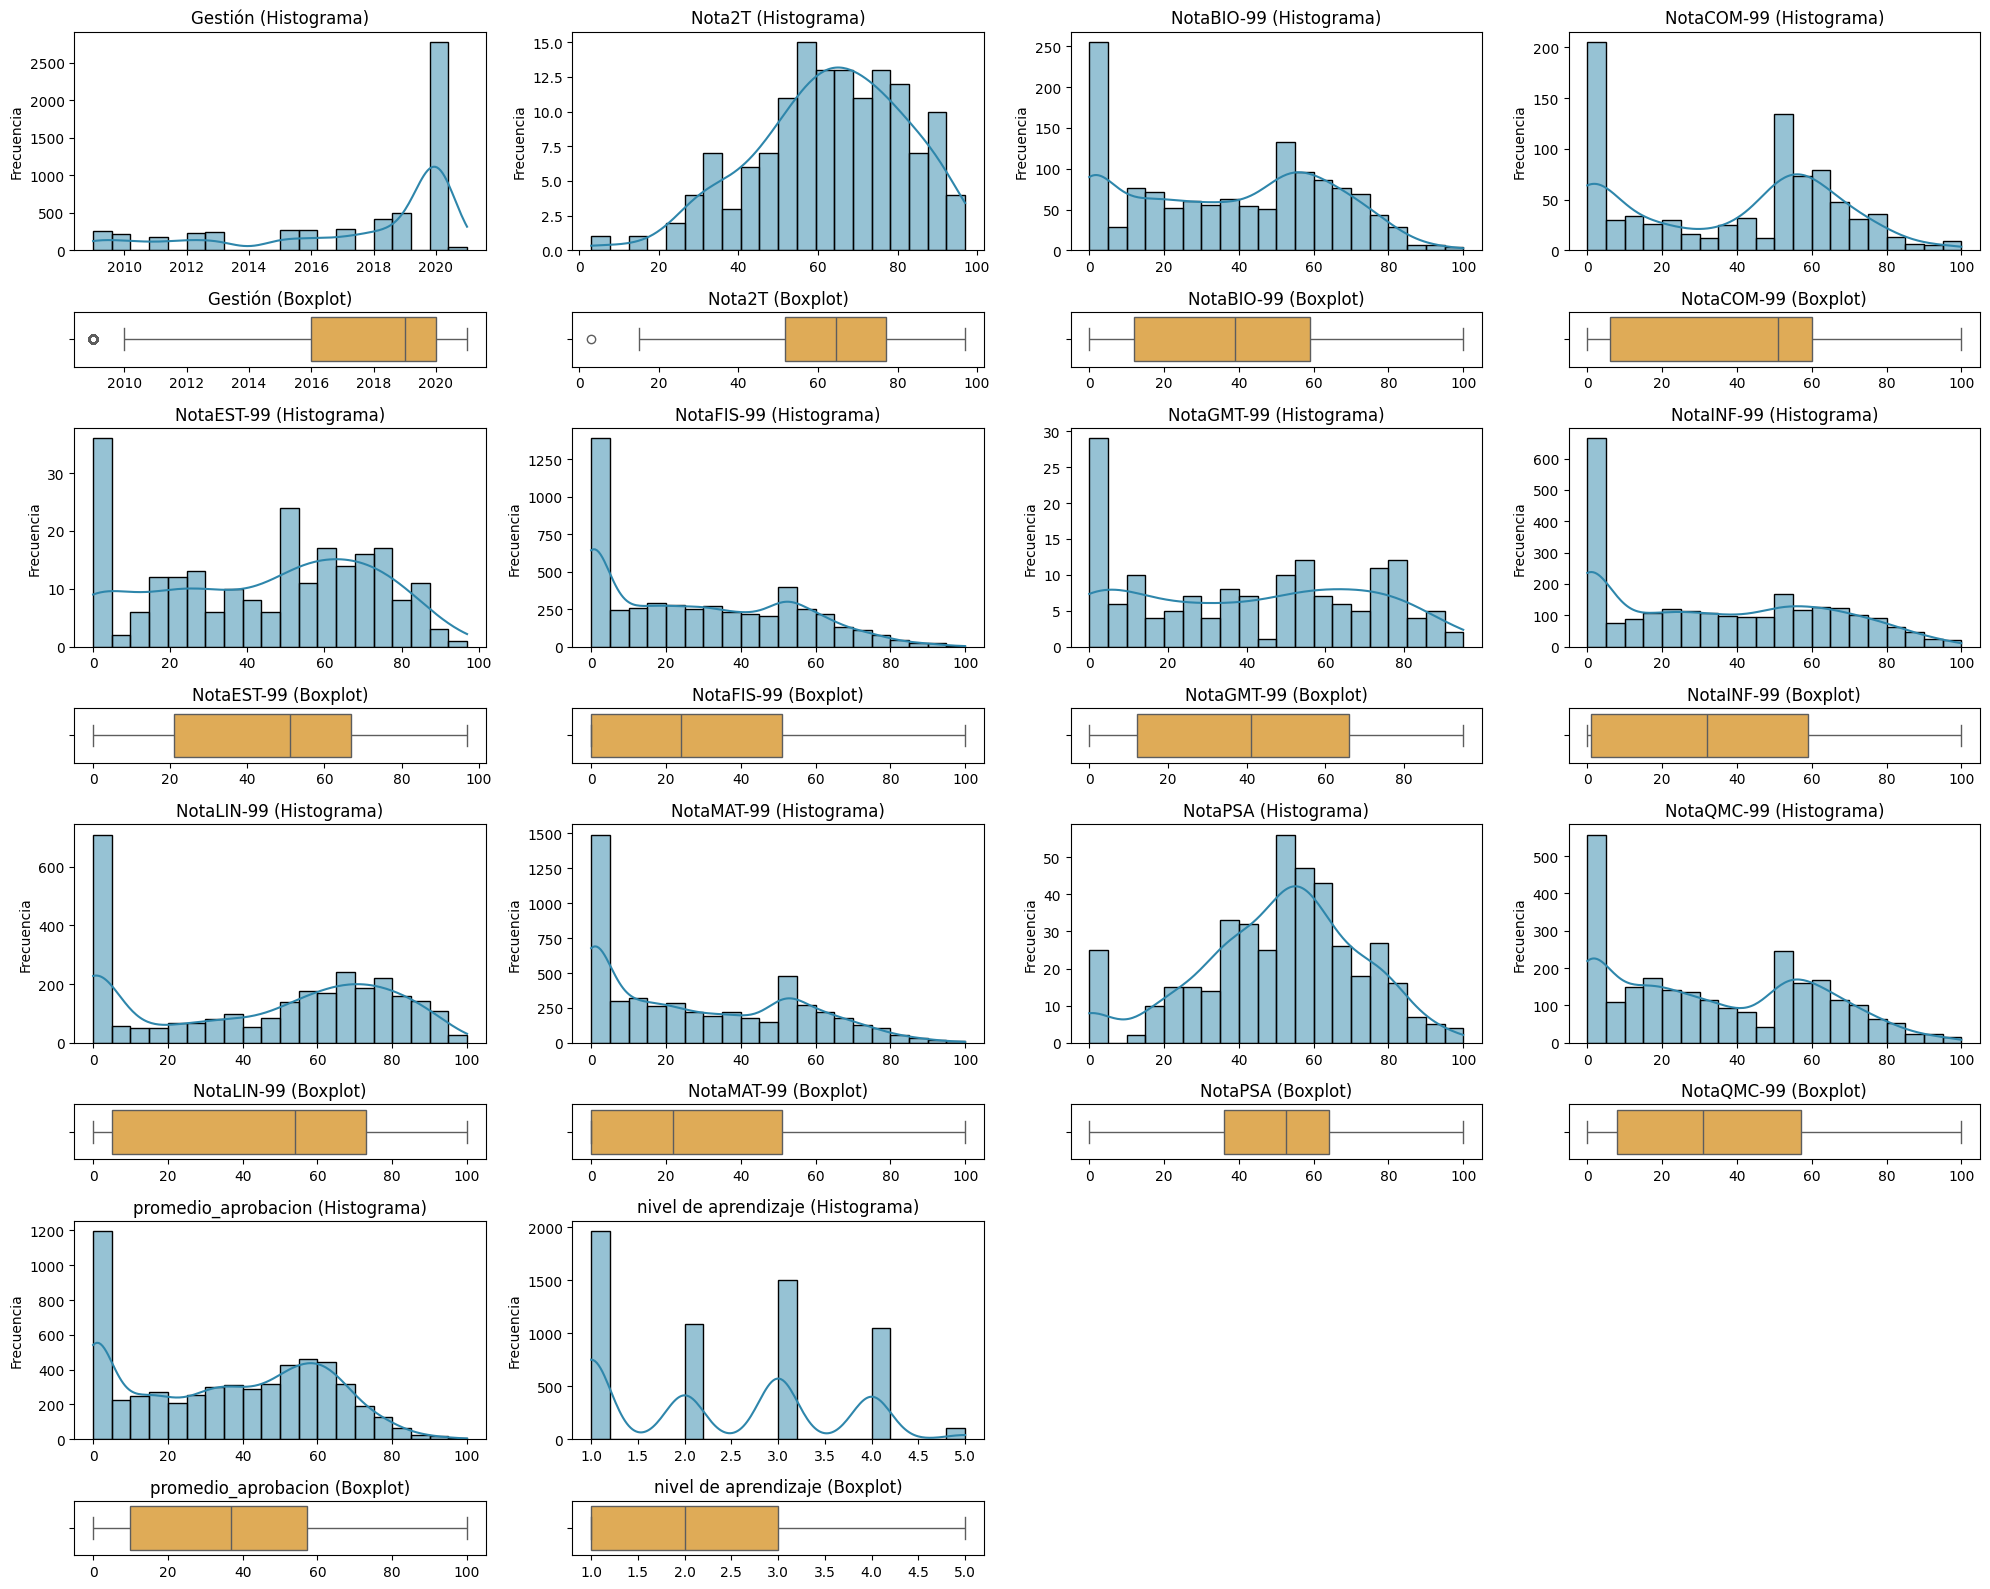

In [54]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Seleccionar variables numéricas ---
num_cols = [c for c in df_wide.columns if df_wide[c].dtype in ['int64', 'float64']]

print("Variables numéricas detectadas:")
for i, col in enumerate(num_cols, start=1):
    print(f"{i}: {col}")

# --- Función para graficar histograma + boxplot ignorando -1 ---
def plot_num_with_box(data, cols):
    n = len(cols)
    cols_per_row = 4
    n_rows = math.ceil(n / cols_per_row)

    fig, axes = plt.subplots(2 * n_rows, cols_per_row,
                             figsize=(5 * cols_per_row, 4 * n_rows),
                             gridspec_kw={'height_ratios': [4, 1] * n_rows})

    axes = np.array(axes).reshape(2*n_rows, cols_per_row)

    for idx, col in enumerate(cols):
        row = (idx // cols_per_row) * 2
        col_idx = idx % cols_per_row
        num = idx + 1

        # --- Filtrar valores válidos (ignorar -1) ---
        col_data = data[col][data[col] != -1]
        missing = (data[col] == -1).sum() + data[col].isna().sum()

        if len(col_data) == 0:
            print(f"\n{num}: {col} -> No hay datos válidos para graficar")
            axes[row, col_idx].text(0.5, 0.5, "Sin datos válidos",
                                    ha='center', va='center')
            axes[row+1, col_idx].text(0.5, 0.5, "Sin datos válidos",
                                      ha='center', va='center')
            axes[row, col_idx].set_title(f"{col} (Histograma)")
            axes[row+1, col_idx].set_title(f"{col} (Boxplot)")
            continue

        q1 = col_data.quantile(0.25)
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        outliers = col_data[(col_data < q1 - 1.5*iqr) | (col_data > q3 + 1.5*iqr)]

        print(f"\n{num}: {col}")
        print(f"  Faltantes (-1 o NaN): {missing}")
        print(f"  Min: {col_data.min()}  Max: {col_data.max()}")
        print(f"  Media: {col_data.mean():.2f}  Mediana: {col_data.median()}")
        print(f"  IQR: {iqr}  Outliers: {len(outliers)}")

        # --- Histograma ---
        sns.histplot(col_data, bins=20, kde=True, ax=axes[row, col_idx], color='#2E86AB')
        axes[row, col_idx].set_title(f"{col} (Histograma)")
        axes[row, col_idx].set_xlabel("")
        axes[row, col_idx].set_ylabel("Frecuencia")

        # --- Boxplot ---
        if col_data.nunique() >= 2:
            sns.boxplot(x=col_data, ax=axes[row + 1, col_idx], color='#F5B041')
        else:
            axes[row + 1, col_idx].text(0.5, 0.5, "Sin datos suficientes",
                                        ha='center', va='center')
        axes[row + 1, col_idx].set_title(f"{col} (Boxplot)")
        axes[row + 1, col_idx].set_xlabel("")
        axes[row + 1, col_idx].set_ylabel("")

    # Ocultar casillas vacías
    total_cells = n_rows * cols_per_row
    for j in range(n, total_cells):
        r = (j // cols_per_row) * 2
        c = j % cols_per_row
        axes[r, c].set_visible(False)
        axes[r+1, c].set_visible(False)

    plt.tight_layout()
    plt.show()

# --- Ejecutar ---
plot_num_with_box(df_wide, num_cols)


Variables numéricas detectadas:
1: Gestión
2: Nota2T
3: NotaBIO-99
4: NotaCOM-99
5: NotaEST-99
6: NotaFIS-99
7: NotaGMT-99
8: NotaINF-99
9: NotaLIN-99
10: NotaMAT-99
11: NotaPSA
12: NotaQMC-99
13: promedio_aprobacion
14: nivel de aprendizaje


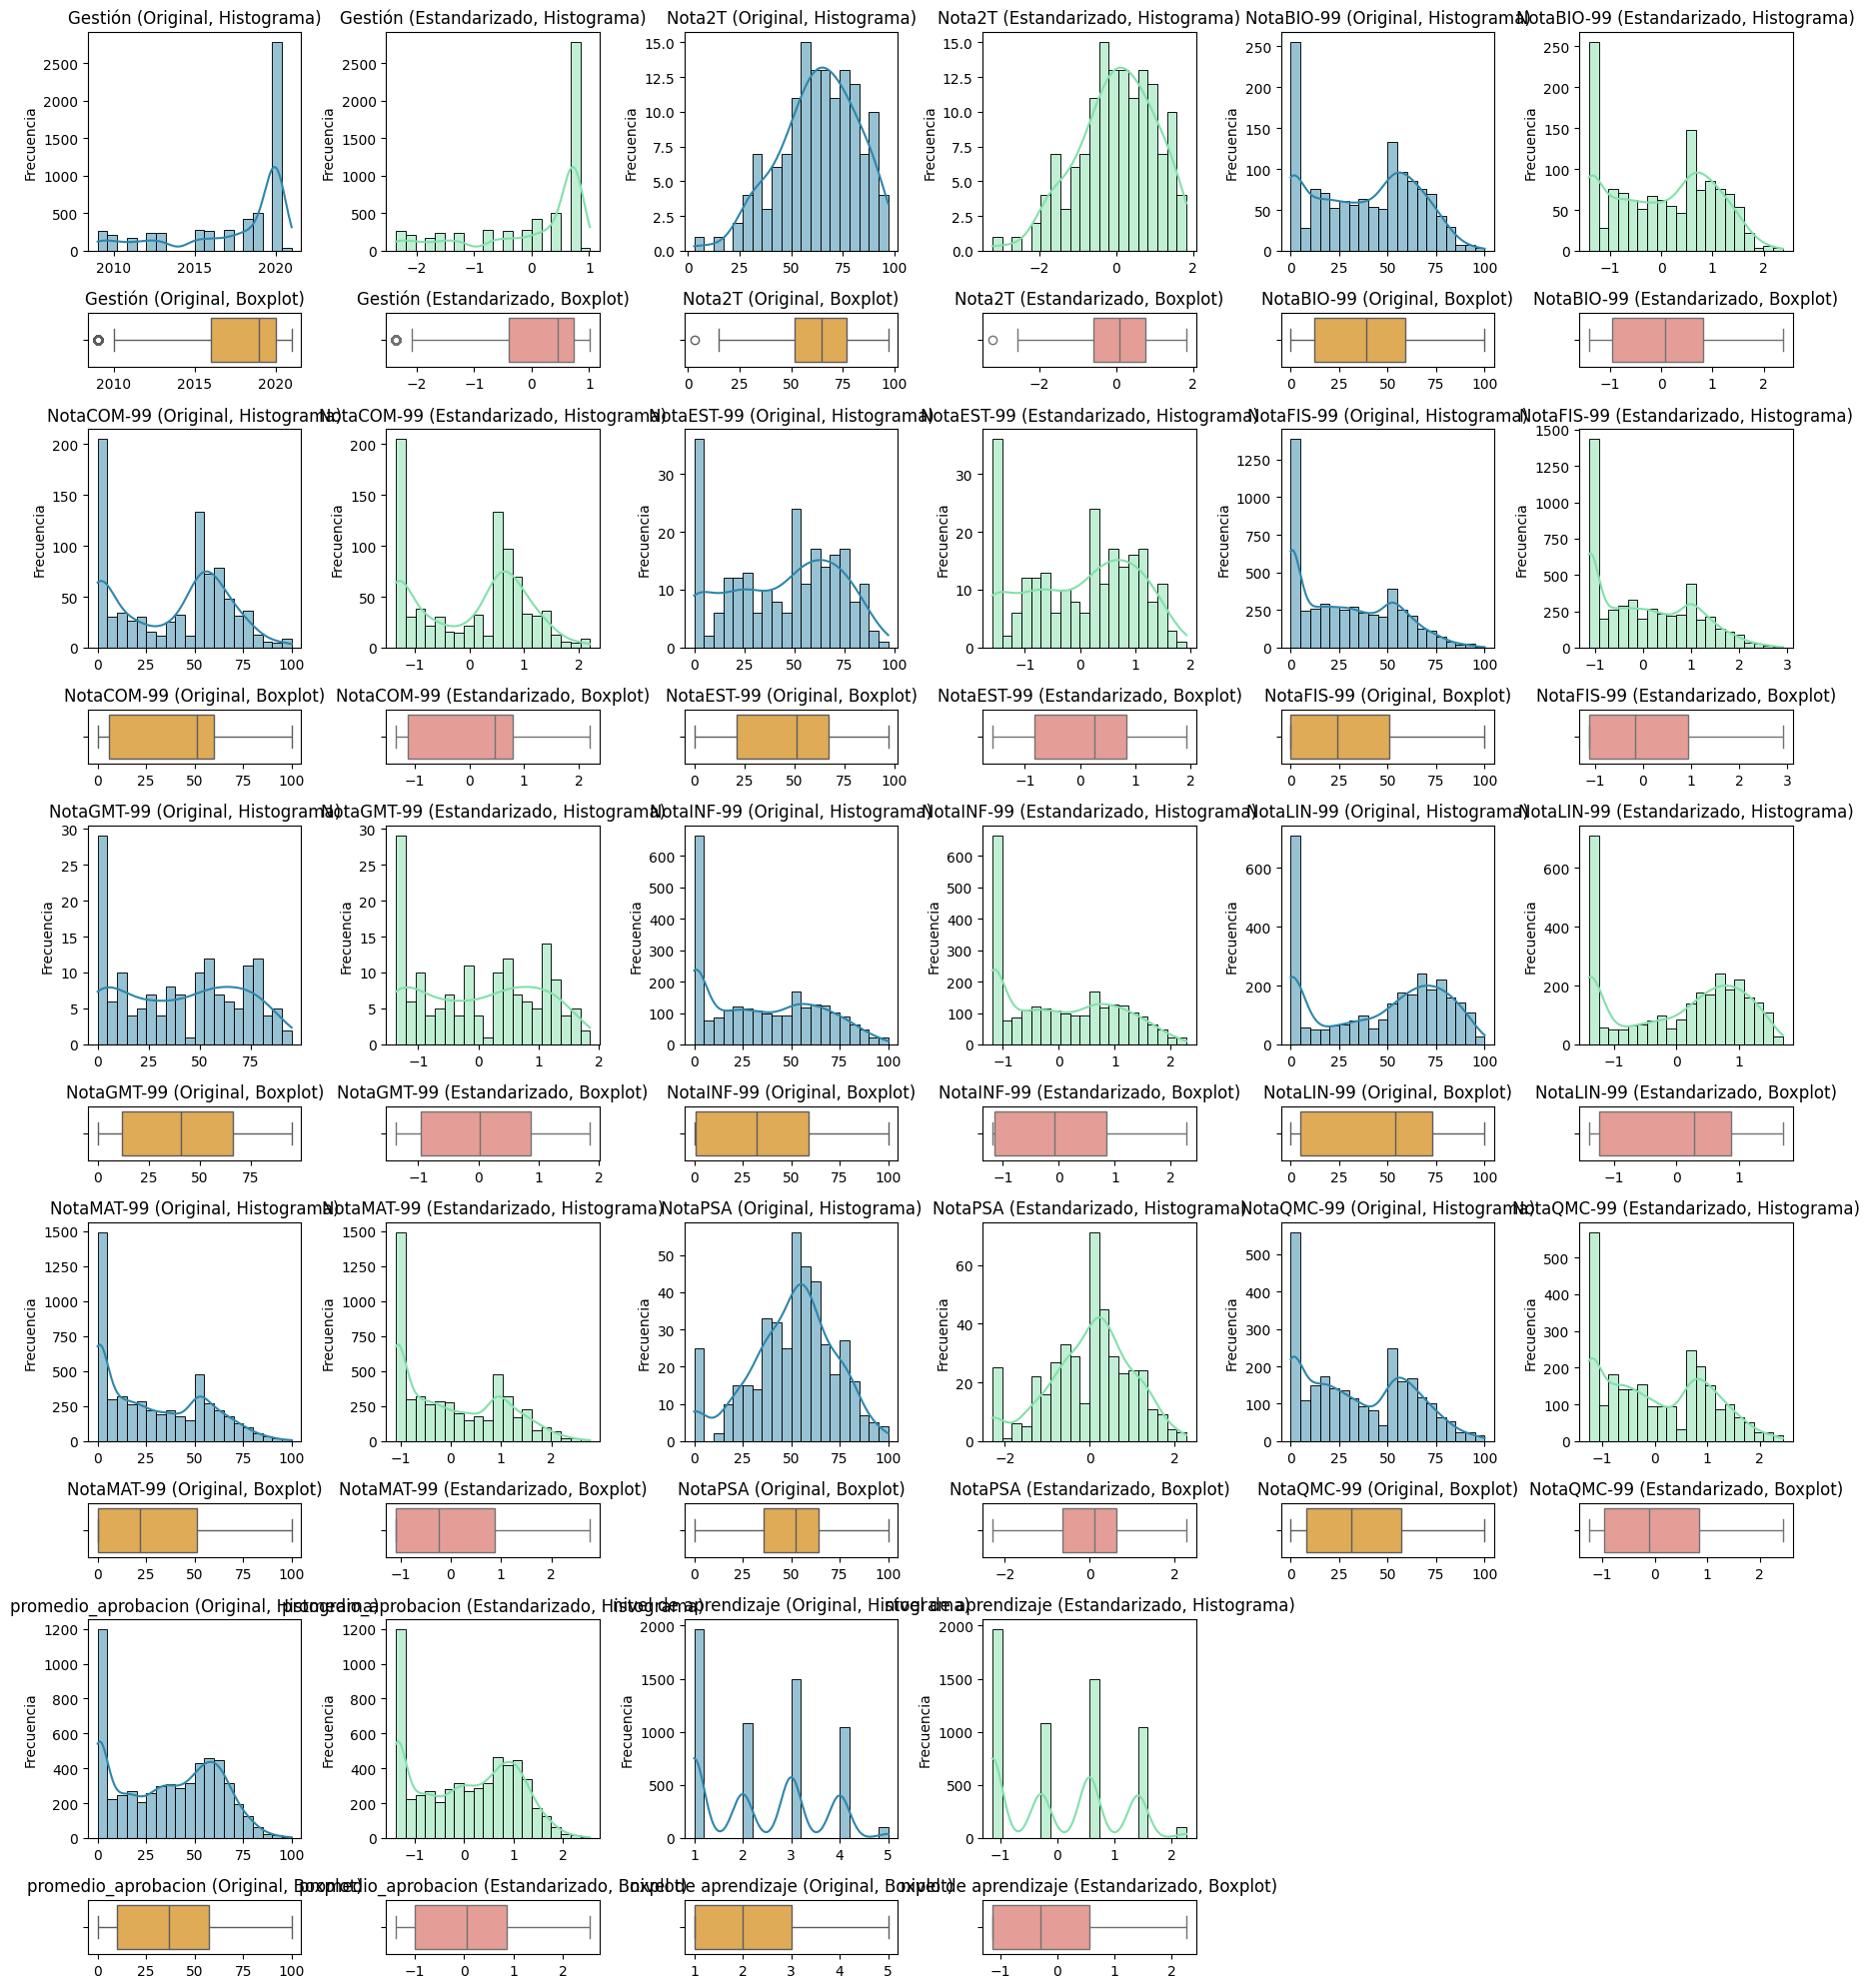

In [55]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Seleccionar variables numéricas ---
num_cols = [c for c in df_wide.columns if df_wide[c].dtype in ['int64', 'float64']]
print("Variables numéricas detectadas:")
for i, col in enumerate(num_cols, start=1):
    print(f"{i}: {col}")

# --- Crear copia para estandarizar ---
df_std = df_wide.copy()

# --- Función para graficar histograma + boxplot original vs estandarizado ---
def plot_num_with_box_std(data, cols):
    n = len(cols)
    cols_per_row = 3  # Ajuste para que se vea bien
    n_rows = math.ceil(n / cols_per_row)

    fig, axes = plt.subplots(2 * n_rows, 2 * cols_per_row, 
                             figsize=(6 * cols_per_row, 4 * n_rows),
                             gridspec_kw={'height_ratios': [4, 1] * n_rows})

    axes = np.array(axes).reshape(2 * n_rows, 2 * cols_per_row)

    scaler = StandardScaler()

    for idx, col in enumerate(cols):
        row = (idx // cols_per_row) * 2
        col_idx = (idx % cols_per_row) * 2

        # --- Filtrar datos válidos ---
        col_data = data[col][data[col] != -1].values.reshape(-1, 1)
        missing = (data[col] == -1).sum() + data[col].isna().sum()

        if len(col_data) == 0:
            axes[row, col_idx].text(0.5, 0.5, "Sin datos válidos", ha='center', va='center')
            axes[row+1, col_idx].text(0.5, 0.5, "Sin datos válidos", ha='center', va='center')
            axes[row, col_idx+1].text(0.5, 0.5, "Sin datos válidos", ha='center', va='center')
            axes[row+1, col_idx+1].text(0.5, 0.5, "Sin datos válidos", ha='center', va='center')
            continue

        # --- Estandarizar ---
        col_std = scaler.fit_transform(col_data).flatten()

        # --- Histograma original ---
        sns.histplot(col_data.flatten(), bins=20, kde=True, ax=axes[row, col_idx], color='#2E86AB')
        axes[row, col_idx].set_title(f"{col} (Original, Histograma)")
        axes[row, col_idx].set_xlabel("")
        axes[row, col_idx].set_ylabel("Frecuencia")

        # --- Histograma estandarizado ---
        sns.histplot(col_std, bins=20, kde=True, ax=axes[row, col_idx+1], color='#82E0AA')
        axes[row, col_idx+1].set_title(f"{col} (Estandarizado, Histograma)")
        axes[row, col_idx+1].set_xlabel("")
        axes[row, col_idx+1].set_ylabel("Frecuencia")

        # --- Boxplot original ---
        sns.boxplot(x=col_data.flatten(), ax=axes[row+1, col_idx], color='#F5B041')
        axes[row+1, col_idx].set_title(f"{col} (Original, Boxplot)")
        axes[row+1, col_idx].set_xlabel("")
        axes[row+1, col_idx].set_ylabel("")

        # --- Boxplot estandarizado ---
        sns.boxplot(x=col_std, ax=axes[row+1, col_idx+1], color='#F1948A')
        axes[row+1, col_idx+1].set_title(f"{col} (Estandarizado, Boxplot)")
        axes[row+1, col_idx+1].set_xlabel("")
        axes[row+1, col_idx+1].set_ylabel("")

    # Ocultar celdas vacías
    total_cells = n_rows * cols_per_row
    for j in range(n, total_cells):
        r = (j // cols_per_row) * 2
        c = (j % cols_per_row) * 2
        axes[r, c].set_visible(False)
        axes[r+1, c].set_visible(False)
        axes[r, c+1].set_visible(False)
        axes[r+1, c+1].set_visible(False)

    plt.tight_layout()
    plt.show()

# --- Ejecutar ---
plot_num_with_box_std(df_wide, num_cols)


# **7) CONVERSION DE DATOS CATEGORICOS**

In [56]:


# --- Seleccionar columnas categóricas (tipo object), excluyendo 'Estado' ---
cat_cols = list(df_wide.select_dtypes(include=['object']).columns)
exclude_cols = ['C.I.', 'Estado']  # no convertir estas
cat_cols = [c for c in cat_cols if c not in exclude_cols]

print("\nColumnas que se codificarán (one-hot):")
if cat_cols:
    print(tabulate([[c] for c in cat_cols], headers=["Columna"], tablefmt="fancy_grid"))
else:
    print("No hay columnas categóricas para codificar.")

# --- Aplicar One-Hot Encoding solo a las categóricas seleccionadas ---
notas_encoded = pd.get_dummies(df_wide, columns=cat_cols, drop_first=False, dtype=int)

# --- Resumen de formas ---
tabla_formas = [
    ["df_wide", df_wide.shape],
    ["notas_encoded", notas_encoded.shape]
]
print("\n=== Resumen de formas de los datasets ===")
print(tabulate(tabla_formas, headers=["Dataset", "Dimensiones"], tablefmt="fancy_grid"))

# --- Mostrar primeras columnas de notas_encoded ---
columnas_muestra = [[i+1, col] for i, col in enumerate(notas_encoded.columns[:30])]
print("\n=== Primeras 30 columnas de notas_encoded ===")
print(tabulate(columnas_muestra, headers=["N°", "Nombre de la columna"], tablefmt="fancy_grid"))

# Vista previa del dataset final
notas_encoded.head()



Columnas que se codificarán (one-hot):
╒═══════════╕
│ Columna   │
╞═══════════╡
│ Carrera   │
├───────────┤
│ Periodo   │
╘═══════════╛

=== Resumen de formas de los datasets ===
╒═══════════════╤═══════════════╕
│ Dataset       │ Dimensiones   │
╞═══════════════╪═══════════════╡
│ df_wide       │ (5691, 18)    │
├───────────────┼───────────────┤
│ notas_encoded │ (5691, 27)    │
╘═══════════════╧═══════════════╛

=== Primeras 30 columnas de notas_encoded ===
╒══════╤═══════════════════════════╕
│   N° │ Nombre de la columna      │
╞══════╪═══════════════════════════╡
│    1 │ Gestión                   │
├──────┼───────────────────────────┤
│    2 │ C.I.                      │
├──────┼───────────────────────────┤
│    3 │ Nota2T                    │
├──────┼───────────────────────────┤
│    4 │ NotaBIO-99                │
├──────┼───────────────────────────┤
│    5 │ NotaCOM-99                │
├──────┼───────────────────────────┤
│    6 │ NotaEST-99                │
├──────┼────────

,Gestión,C.I.,Nota2T,NotaBIO-99,NotaCOM-99,NotaEST-99,NotaFIS-99,NotaGMT-99,NotaINF-99,NotaLIN-99,...,Carrera_Ciencias Químicas,Carrera_Estadística,Carrera_Física,Carrera_Informática,Carrera_Matemática,Periodo_PRIMERO,Periodo_PRIMERO (2T),Periodo_PRIMERO (PSA),Periodo_SEGUNDO,Periodo_SEGUNDO (PSA)
0,2009,4295732,-1.0,60.0,-1.0,-1.0,67.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
1,2009,4299485,-1.0,52.0,-1.0,-1.0,51.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
2,2009,4751856,-1.0,73.0,-1.0,-1.0,55.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
3,2009,4755839,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0
4,2009,4766488,-1.0,18.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,...,0,0,0,0,0,0,0,0,1,0


In [57]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5691 entries, 0 to 5690
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Carrera               5691 non-null   object 
 1   Gestión               5691 non-null   int64  
 2   Periodo               5691 non-null   object 
 3   C.I.                  5691 non-null   object 
 4   Nota2T                5691 non-null   float64
 5   NotaBIO-99            5691 non-null   float64
 6   NotaCOM-99            5691 non-null   float64
 7   NotaEST-99            5691 non-null   float64
 8   NotaFIS-99            5691 non-null   float64
 9   NotaGMT-99            5691 non-null   float64
 10  NotaINF-99            5691 non-null   float64
 11  NotaLIN-99            5691 non-null   float64
 12  NotaMAT-99            5691 non-null   float64
 13  NotaPSA               5691 non-null   float64
 14  NotaQMC-99            5691 non-null   float64
 15  promedio_aprobacion  

# ANALISIS DE DATOS

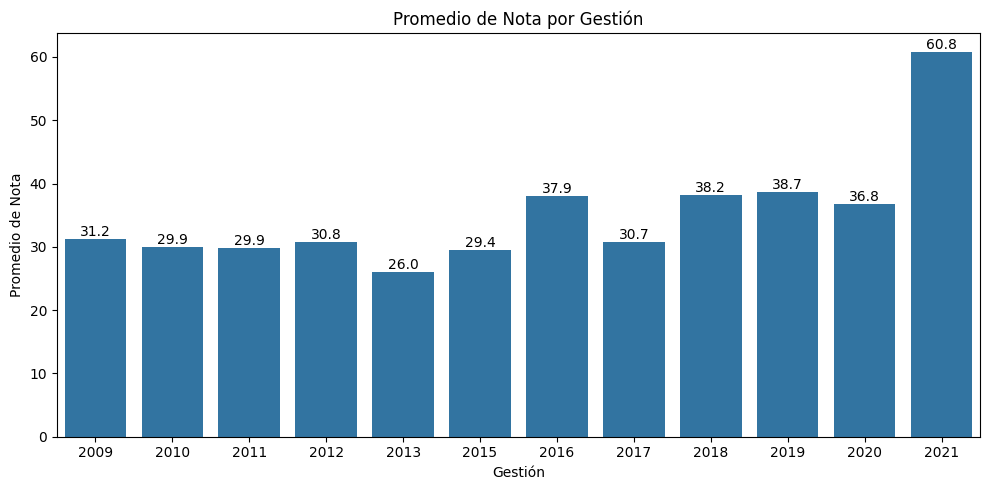

In [58]:
plt.figure(figsize=(10,5))
ax = sns.barplot(data=notas_encoded, x="Gestión", y="promedio_aprobacion", errorbar=None)

# Agregar números a cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("Promedio de Nota por Gestión")
plt.ylabel("Promedio de Nota")
plt.xlabel("Gestión")
plt.tight_layout()
plt.show()


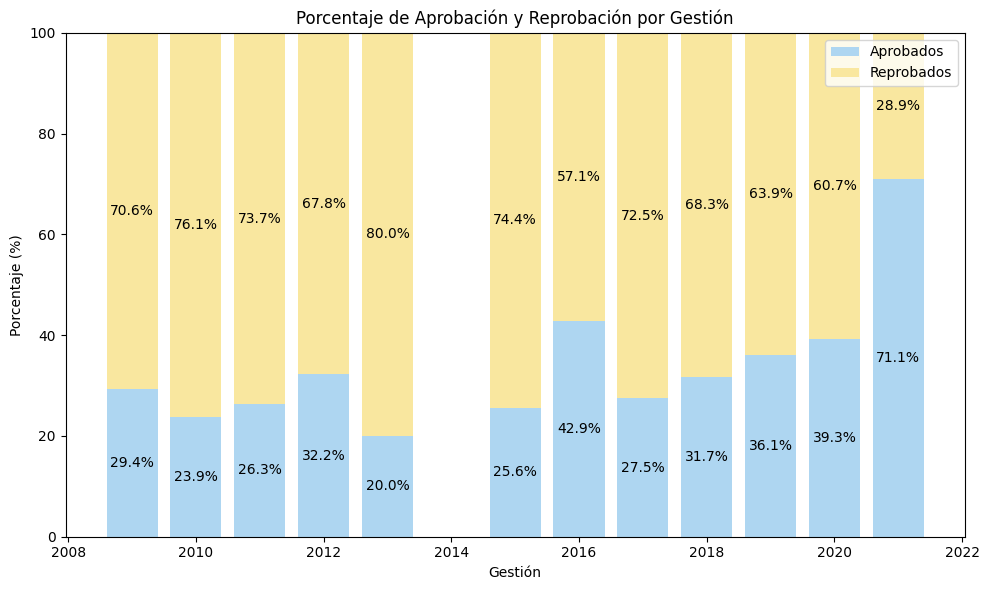

In [59]:
# Convertir Estado a numérico (1,0)
df_wide["Estado"] = pd.to_numeric(df_wide["Estado"], errors="coerce")

# --- Calcular porcentaje de aprobación y reprobación por Gestión ---
porc = df_wide.groupby("Gestión")["Estado"].mean().reset_index()
porc["Aprobados"] = porc["Estado"] * 100
porc["Reprobados"] = 100 - porc["Aprobados"]

# --- Configuración del gráfico ---
plt.figure(figsize=(10,6))

# Colores claros para barras
colors = ["#AED6F1", "#F9E79F"]  # azul claro: aprobados, amarillo claro: reprobados

# Crear barras apiladas
plt.bar(porc["Gestión"], porc["Aprobados"], color=colors[0], label="Aprobados")
plt.bar(porc["Gestión"], porc["Reprobados"], bottom=porc["Aprobados"], color=colors[1], label="Reprobados")

# Añadir valores encima de cada sección
for i, row in porc.iterrows():
    plt.text(row["Gestión"], row["Aprobados"]/2, f"{row['Aprobados']:.1f}%", ha='center', va='center', color='black', fontsize=10)
    plt.text(row["Gestión"], row["Aprobados"] + row["Reprobados"]/2, f"{row['Reprobados']:.1f}%", ha='center', va='center', color='black', fontsize=10)

# Etiquetas y título
plt.title("Porcentaje de Aprobación y Reprobación por Gestión")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Gestión")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

In [60]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Datos ---
df_plot = df_wide.copy()
gestiones = sorted(df_plot["Gestión"].unique())

# --- Slider de rango para seleccionar gestiones ---
slider_gestiones = widgets.SelectionRangeSlider(
    options=gestiones,
    index=(0, len(gestiones)-1),
    description='Gestión:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

output = widgets.Output()
def actualizar_grafico(change):
    with output:
        clear_output()
        # Filtrar según rango seleccionado
        gest_inicio, gest_fin = slider_gestiones.value
        gest_seleccionadas = [g for g in gestiones if gest_inicio <= g <= gest_fin]
        if not gest_seleccionadas:
            print("Selecciona al menos una gestión")
            return

        df_filtrado = df_plot[df_plot["Gestión"].isin(gest_seleccionadas)]

        # Calcular totales de aprobados y reprobados por Carrera y Gestión
        resumen = df_filtrado.groupby(["Carrera", "Gestión"])["Estado"].agg(['mean','sum','count']).reset_index()
        resumen["Aprobados"] = resumen["sum"]               # Total de aprobados
        resumen["Reprobados"] = resumen["count"] - resumen["sum"]  # Total de reprobados
        resumen["Porc_Aprobados"] = resumen["mean"] * 100
        resumen["Porc_Reprobados"] = 100 - resumen["Porc_Aprobados"]

        # Transformar a formato largo para Plotly
        porc_long = pd.DataFrame({
            "Carrera": resumen["Carrera"].tolist() * 2,
            "Gestión": resumen["Gestión"].tolist() * 2,
            "Resultado": ["Aprobados"]*len(resumen) + ["Reprobados"]*len(resumen),
            "Porcentaje": list(resumen["Porc_Aprobados"]) + list(resumen["Porc_Reprobados"]),
            "Cantidad": list(resumen["Aprobados"]) + list(resumen["Reprobados"])
        })

        fig = px.bar(
            porc_long,
            x="Carrera",
            y="Porcentaje",
            color="Resultado",
            barmode="group",
            facet_col="Gestión",
            color_discrete_map={"Aprobados":"#85C1E9", "Reprobados":"#F9E79F"},
            height=500,
            title="Porcentaje de Aprobación y Reprobación",
            hover_data={"Porcentaje": ':.2f', "Cantidad": True}
        )

        fig.update_layout(
            title=dict(x=0.5, y=0.97, xanchor='center', yanchor='top', font=dict(size=20)),
            legend=dict(title="", orientation="h", yanchor="top", y=1.27, xanchor="center", x=0.5),
            margin=dict(t=140, b=50),
            xaxis_title="", 
            yaxis_title=""
        )
        fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
        fig.show()



# --- Observar cambios ---
slider_gestiones.observe(actualizar_grafico, names='value')

# --- Contenedor centrado para el slider ---
slider_box = widgets.HBox([slider_gestiones], layout=widgets.Layout(justify_content='center'))

# --- Mostrar ---
display(slider_box, output)
# --- Primera ejecución ---
actualizar_grafico(None)


Output()

In [61]:
# Filtrar por Gestión 2020 y Carrera "Ciencias Químicas"
df_filtrado = df_wide[(df_wide["Gestión"] == 2020) & (df_wide["Carrera"] == "Ciencias Químicas")]

# Total de estudiantes
total_estudiantes = len(df_filtrado)

# Total de aprobados (Estado = 1)
total_aprobados = df_filtrado["Estado"].sum()

# Total de reprobados
total_reprobados = total_estudiantes - total_aprobados

# Mostrar
print(f"Gestión 2020 - Ciencias Químicas")
print(f"Total de estudiantes: {total_estudiantes}")
print(f"Aprobados: {total_aprobados}")
print(f"Reprobados: {total_reprobados}")


Gestión 2020 - Ciencias Químicas
Total de estudiantes: 88
Aprobados: 47
Reprobados: 41


In [62]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# ================================================
# 1) Detectar todas las columnas de materias
# ================================================
columnas_materias = [c for c in df_wide.columns if c.startswith("Nota")]

# ================================================
# 2) Función de análisis por carrera y gestión
# ================================================
def analizar_dificultad_por_carrera(df, carrera, gestion):
    df_car = df[(df["Carrera"] == carrera) & (df["Gestión"] == gestion)].copy()
    resultados = []

    for col in columnas_materias:

        # Filtrar solo notas válidas (≠ -1)
        notas_validas = df_car[col][df_car[col] != -1]

        if notas_validas.empty:
            continue  # esta carrera no cursa esta materia

        materia = col.replace("Nota", "")
        total = len(notas_validas)
        aprob = (notas_validas >= 51).sum()
        reprob = (notas_validas < 51).sum()

        resultados.append({
            "Materia": materia,
            "Promedio": notas_validas.mean(),
            "Mediana": notas_validas.median(),
            "Nota mínima": notas_validas.min(),
            "Nota máxima": notas_validas.max(),
            "Total estudiantes": total,
            "Aprobados": aprob,
            "Reprobados": reprob,
            "% Reprobados": (reprob / total) * 100
        })

    df_result = pd.DataFrame(resultados)
    return df_result

# ================================================
# 3) Widgets (selector de carrera y gestión)
# ================================================
carreras = sorted(df_wide["Carrera"].unique())
gestiones = sorted(df_wide["Gestión"].unique())

selector_carrera = widgets.Dropdown(
    options=carreras,
    description="Carrera:",
    layout=widgets.Layout(width="300px")
)

selector_gestion = widgets.Dropdown(
    options=gestiones,
    description="Gestión:",
    layout=widgets.Layout(width="150px")
)

salida = widgets.Output()

# ================================================
# 4) Función para graficar
# ================================================
def actualizar_graficos(change):
    with salida:
        clear_output()

        carrera = selector_carrera.value
        gestion = selector_gestion.value

        df_res = analizar_dificultad_por_carrera(df_wide, carrera, gestion)

        if df_res.empty:
            print("No hay datos válidos para esta carrera y gestión.")
            return

        # =========================
        # Boxplot por materia (distribución real)
        # =========================
        df_car = df_wide[(df_wide["Carrera"] == carrera) & (df_wide["Gestión"] == gestion)].copy()
        df_long = df_car.melt(
            id_vars=["Carrera"],
            value_vars=columnas_materias,
            var_name="Materia",
            value_name="Nota"
        )
        df_long = df_long[df_long["Nota"] != -1]
        df_long["Materia"] = df_long["Materia"].str.replace("Nota", "")

        fig_box = px.box(
            df_long,
            x="Materia",
            y="Nota",
            title=f"Distribución de notas por materia – {carrera} ({gestion})",
            points="all"
        )
        fig_box.update_layout(yaxis_title="Nota", xaxis_title="Materia")
        fig_box.show()

        # =========================
        # Promedio por materia
        # =========================
        fig_prom = px.bar(
            df_res.sort_values("Promedio"),
            x="Materia",
            y="Promedio",
            title=f"Promedio de notas por materia – {carrera} ({gestion})",
            color="Promedio",
            color_continuous_scale="Blues",
            text="Promedio"
        )
        fig_prom.update_traces(texttemplate='%{text:.1f}', textposition='outside')
        fig_prom.update_layout(yaxis_title="Promedio", xaxis_title="Materia")
        fig_prom.show()


# ================================================
# 5) Conectar eventos de los selectores
# ================================================
selector_carrera.observe(actualizar_graficos, names="value")
selector_gestion.observe(actualizar_graficos, names="value")

# ================================================
# 6) Mostrar interfaz
# ================================================
display(widgets.HBox([selector_carrera, selector_gestion]), salida)

# Ejecutar primera vez
actualizar_graficos(None)

Output()

In [63]:
notas_encoded.to_csv("data/modelos/datos_prepro_notas.csv", index=False, encoding="utf-8")


In [64]:
notas_encoded.shape

(5691, 27)